# Bengali Hate Speech — Complete NLP Analysis
**Dataset:** `Bengali_hate_speech_.csv` — 30,000 real Bengali sentences  
**Task:** Binary Classification → Hate (1) vs Non-Hate (0)  
**Every technique applied directly on the Bengali dataset**

---
| # | Section |
|---|---------|
| 1 | EDA — Dataset Overview |
| 2 | Text Normalization |
| 3 | Tokenization & Stopword Removal |
| 4 | Stemming (Bengali) |
| 5 | Lemmatization & POS-Aware Lemmatization |
| 6 | POS Tagging |
| 7 | Transformation-Based Tagging (TBT) |
| 8 | One-Hot Encoding |
| 9 | Bag of Words |
| 10 | N-Gram Features |
| 11 | TF-IDF |
| 12 | Latent Semantic Analysis (LSA) |
| 13 | Word2Vec on Bengali |
| 14 | GloVe Co-occurrence |
| 15 | BERT Fine-tuning Code |
| 16 | Naive Bayes |
| 17 | Logistic Regression |
| 18 | SVM |
| 19 | Random Forest |
| 20 | ANN (NumPy from scratch) |
| 21 | RNN (NumPy from scratch) |
| 22 | LSTM (NumPy from scratch) |
| 23 | GRU (NumPy from scratch) |
| 24 | Seq2Seq + Attention |
| 25 | Transformer Self-Attention |
| 26 | Grand Final Comparison |


## Setup & Imports

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn gensim nltk -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.3 MB/s eta 0:00:00


In [5]:
import warnings, re, os
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_curve, auc,
                              precision_recall_curve)
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize
from sklearn.feature_selection import chi2
from gensim.models import Word2Vec

# Dark theme
plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#c9d1d9',
    'xtick.color':'#c9d1d9','ytick.color':'#c9d1d9',
    'text.color':'#c9d1d9','grid.color':'#21262d',
    'grid.linestyle':'--','font.family':'DejaVu Sans',
})
P = ['#58a6ff','#f78166','#3fb950','#d2a8ff','#ffa657','#79c0ff','#ff7eb6','#56d364']
print("All imports ready")

All imports ready


---
## Section 1 — Exploratory Data Analysis (EDA)
Direct analysis of 30,000 Bengali sentences.


In [6]:
df = pd.read_csv("/content/Bengali hate speech .csv")
df['sentence'] = df['sentence'].astype(str)
df['word_count'] = df['sentence'].str.split().str.len()
df['char_count'] = df['sentence'].str.len()

print("="*55)
print("  DATASET OVERVIEW")
print("="*55)
print(f"  Rows       : {len(df):,}")
print(f"  Columns    : {list(df.columns)}")
print(f"  Nulls      : {df.isnull().sum().to_dict()}")
print(f"  Hate dist  : {df['hate'].value_counts().to_dict()}")
print(f"  Categories : {df['category'].nunique()}")
print()
display(df.sample(5, random_state=42)[['sentence','hate','category']])

  DATASET OVERVIEW
  Rows       : 30,000
  Columns    : ['sentence', 'hate', 'category', 'word_count', 'char_count']
  Nulls      : {'sentence': 0, 'hate': 0, 'category': 0, 'word_count': 0, 'char_count': 0}
  Hate dist  : {0: 20000, 1: 10000}
  Categories : 7



,sentence,hate,category
2308,হাইরে হালার পরিচালক হালা নিজেও গানজা খোর আর না...,1,entertainment
22404,কোথায় খালেদা জিয়া? আর কোথায় কাউয়া হাম বা বে ...,0,politics
23397,অপু উকিল কে বলতে দিন না হয় বয়স না হলেও বারিয়ে ...,0,politics
25058,বাচ্চা ছেলেদের আন্দোলন বলতে কি বোঝাল জাফর ব্যা...,0,celebrity
2664,আই তোরে চুদি,1,entertainment


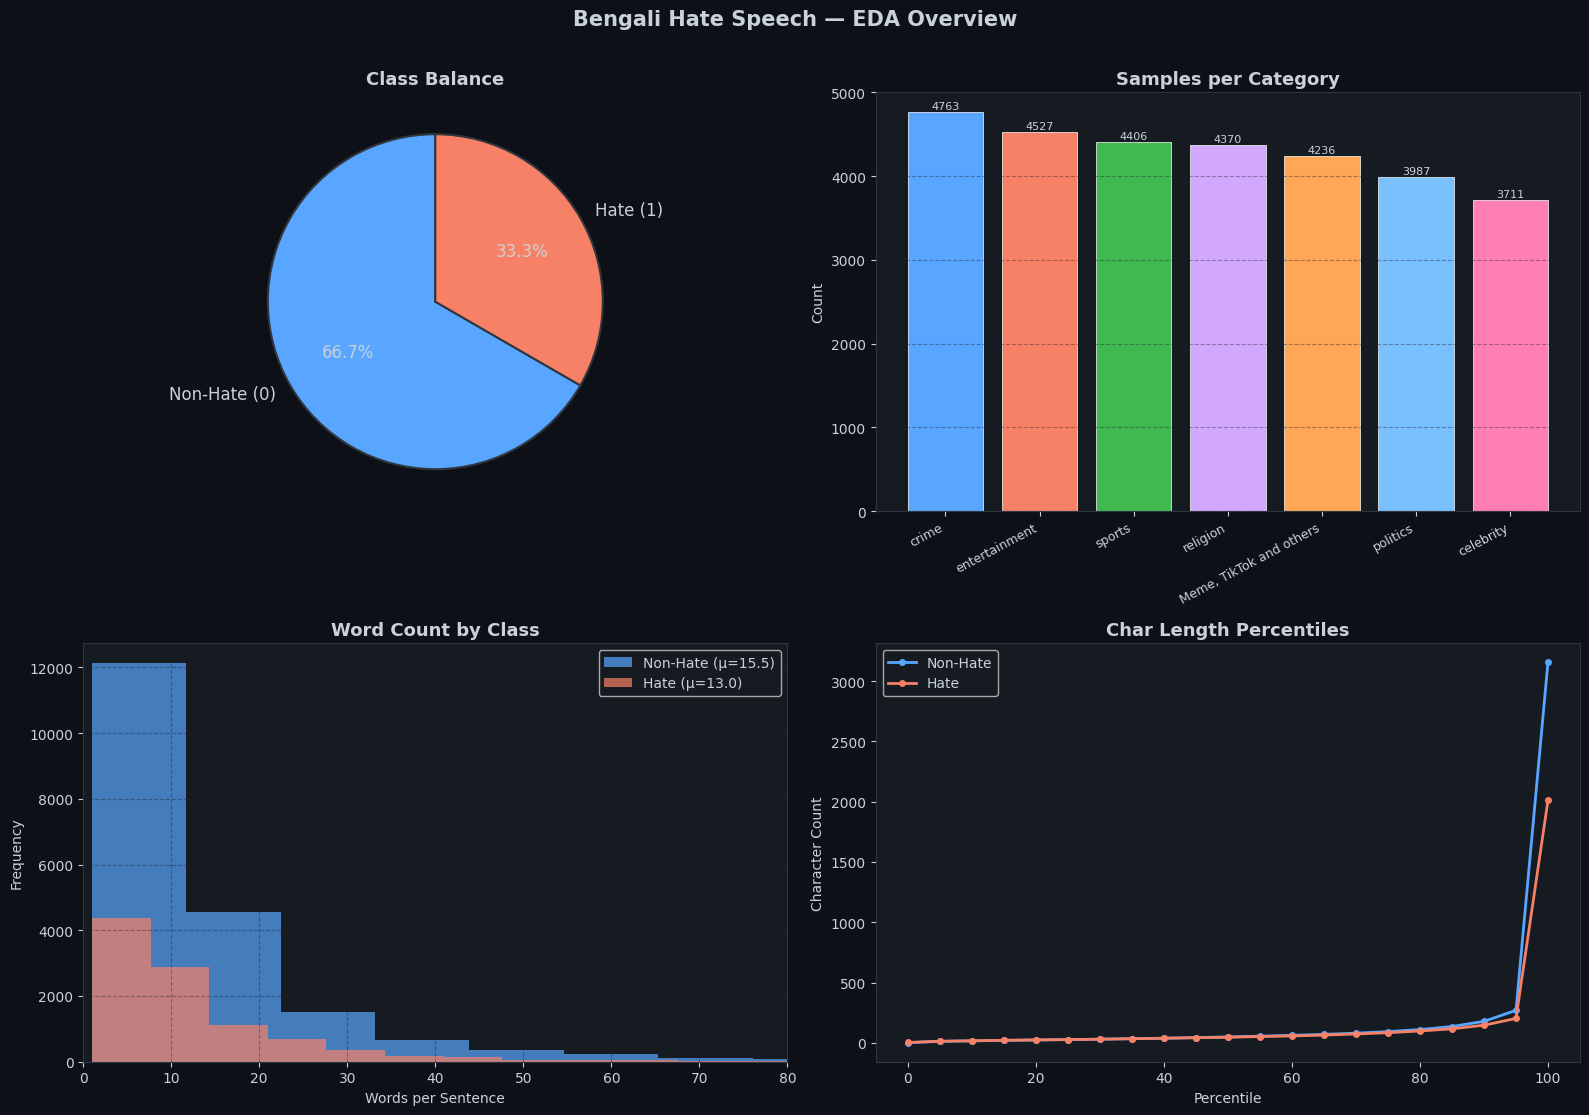

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Bengali Hate Speech — EDA Overview", fontsize=15, fontweight='bold', y=1.01)

# Class pie
hc = df['hate'].value_counts()
axes[0,0].pie(hc, labels=['Non-Hate (0)','Hate (1)'], colors=[P[0],P[1]],
              autopct='%1.1f%%', startangle=90,
              textprops={'color':'#c9d1d9','fontsize':12},
              wedgeprops={'edgecolor':'#30363d','linewidth':1.5})
axes[0,0].set_title("Class Balance", fontsize=13, fontweight='bold')

# Category bar
cc = df['category'].value_counts()
bars = axes[0,1].bar(range(len(cc)), cc.values, color=P[:len(cc)], edgecolor='white', lw=0.5)
axes[0,1].set_xticks(range(len(cc)))
axes[0,1].set_xticklabels(cc.index, rotation=28, ha='right', fontsize=9)
axes[0,1].set_title("Samples per Category", fontsize=13, fontweight='bold')
axes[0,1].set_ylabel("Count"); axes[0,1].grid(axis='y', alpha=0.4)
for bar,v in zip(bars, cc.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+40, str(v), ha='center', fontsize=8)

# Word count by class
for label,color in [(0,P[0]),(1,P[1])]:
    d = df[df['hate']==label]['word_count']
    axes[1,0].hist(d, bins=50, alpha=0.7, color=color,
                   label=f"{'Hate' if label else 'Non-Hate'} (μ={d.mean():.1f})")
axes[1,0].set_xlim(0,80); axes[1,0].set_title("Word Count by Class", fontsize=13, fontweight='bold')
axes[1,0].set_xlabel("Words per Sentence"); axes[1,0].set_ylabel("Frequency")
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.4)

# Char length percentiles
for label,color,name in [(0,P[0],'Non-Hate'),(1,P[1],'Hate')]:
    pcts = np.arange(0,101,5)
    vals = np.percentile(df[df['hate']==label]['char_count'], pcts)
    axes[1,1].plot(pcts, vals, 'o-', color=color, lw=2, ms=4, label=name)
axes[1,1].set_title("Char Length Percentiles", fontsize=13, fontweight='bold')
axes[1,1].set_xlabel("Percentile"); axes[1,1].set_ylabel("Character Count")
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

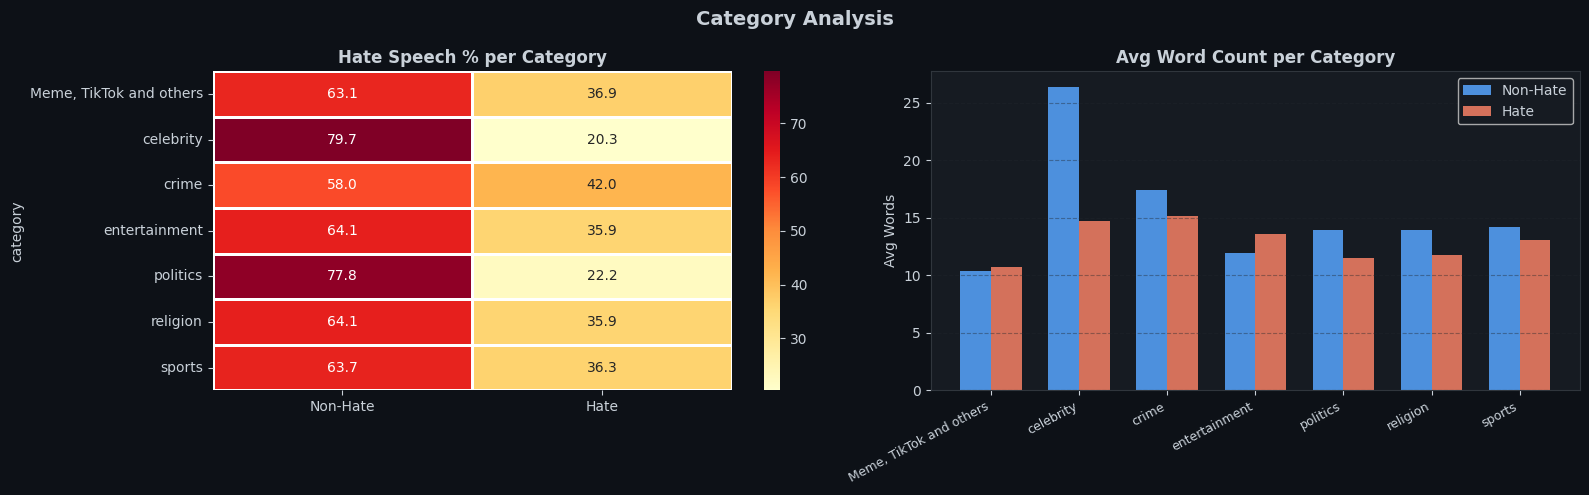

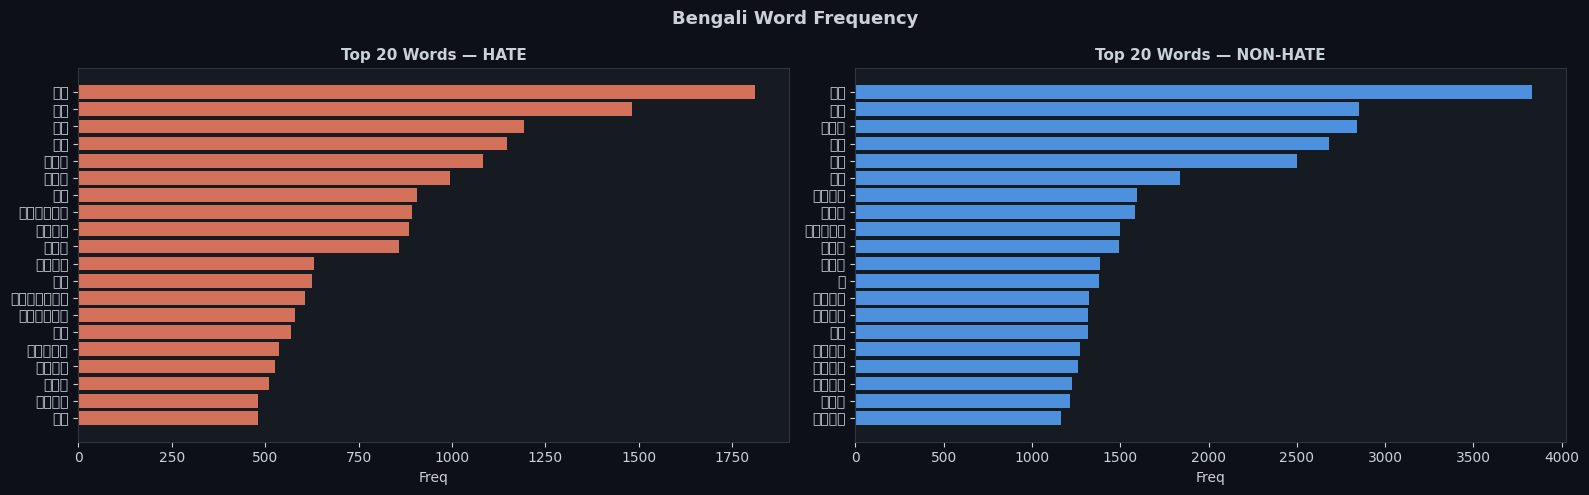

Unique words: 64,323  |  Hate: 24,389  |  Non-Hate: 51,394


In [8]:
# Hate % per category heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Category Analysis", fontsize=14, fontweight='bold')

pivot = df.groupby(['category','hate']).size().unstack(fill_value=0)
pivot.columns = ['Non-Hate','Hate']
pivot_pct = pivot.div(pivot.sum(1), axis=0)*100
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.8)
axes[0].set_title("Hate Speech % per Category", fontsize=12, fontweight='bold')

# Word count by category & class
cat_wc = df.groupby(['category','hate'])['word_count'].mean().unstack()
cat_wc.columns = ['Non-Hate','Hate']
x = np.arange(len(cat_wc)); w=0.35
axes[1].bar(x-w/2, cat_wc['Non-Hate'], w, color=P[0], label='Non-Hate', alpha=0.85)
axes[1].bar(x+w/2, cat_wc['Hate'],     w, color=P[1], label='Hate',     alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(cat_wc.index, rotation=28, ha='right', fontsize=9)
axes[1].set_title("Avg Word Count per Category", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Avg Words"); axes[1].legend(); axes[1].grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

# Word frequency analysis
all_words    = ' '.join(df['sentence']).split()
hate_words   = ' '.join(df[df['hate']==1]['sentence']).split()
nh_words     = ' '.join(df[df['hate']==0]['sentence']).split()
hate_freq    = Counter(hate_words)
nh_freq      = Counter(nh_words)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Bengali Word Frequency", fontsize=13, fontweight='bold')
top20h  = hate_freq.most_common(20)
top20nh = nh_freq.most_common(20)
axes[0].barh([w[0] for w in reversed(top20h)], [w[1] for w in reversed(top20h)], color=P[1], alpha=0.85)
axes[0].set_title("Top 20 Words — HATE",     fontsize=11, fontweight='bold'); axes[0].set_xlabel("Freq")
axes[1].barh([w[0] for w in reversed(top20nh)],[w[1] for w in reversed(top20nh)],color=P[0], alpha=0.85)
axes[1].set_title("Top 20 Words — NON-HATE", fontsize=11, fontweight='bold'); axes[1].set_xlabel("Freq")
plt.tight_layout(); plt.show()
print(f"Unique words: {len(Counter(all_words)):,}  |  Hate: {len(hate_freq):,}  |  Non-Hate: {len(nh_freq):,}")

---
## Section 2 — Text Normalization on Bengali Text
Keeping only Bengali Unicode (U+0980–U+09FF) + spaces.


In [9]:
def normalize_bengali(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)             # @mentions, #hashtags
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)  # keep Bengali Unicode only
    text = re.sub(r'\s+', ' ', text).strip()           # collapse whitespace
    return text

df['normalized'] = df['sentence'].apply(normalize_bengali)
df['norm_char']  = df['normalized'].str.len()
removed_pct = ((df['char_count'] - df['norm_char']) / df['char_count'].clip(1) * 100).clip(0)

print("Normalization Examples:")
print("="*70)
for _, row in df.sample(5, random_state=7).iterrows():
    print(f"  Orig : {row['sentence'][:65]}")
    print(f"  Norm : {row['normalized'][:65]}")
    print(f"  Label: {'HATE' if row['hate'] else 'NON-HATE'} | Cat: {row['category']}\n")

Normalization Examples:
  Orig : শালারপুতেরা বিবেকহীন উদীয়মান ক্রিকেটার মুশফিককে নির্বাচিত না করে 
  Norm : শালারপুতেরা বিবেকহীন উদীয়মান ক্রিকেটার মুশফিককে নির্বাচিত না করে 
  Label: HATE | Cat: sports

  Orig : গরীব বেয়াদব মদ খায় সালারপুত মদ না খাইলে তোগো বুদ্ধি হইবো না।
  Norm : গরীব বেয়াদব মদ খায় সালারপুত মদ না খাইলে তোগো বুদ্ধি হইবো না
  Label: NON-HATE | Cat: sports

  Orig : শালার কুত্তাটাকে পেলে গলায় পারা দিয়ে মেরে ফেলতাম শুয়োর কোথাকার
  Norm : শালার কুত্তাটাকে পেলে গলায় পারা দিয়ে মেরে ফেলতাম শুয়োর কোথাকার
  Label: HATE | Cat: Meme, TikTok and others

  Orig : ভিপি নূর নিজেকে বড় নেতা ভাবছেন। সালার হোগার ভিতরে ডিম ঢুকিয়ে দি
  Norm : ভিপি নূর নিজেকে বড় নেতা ভাবছেন সালার হোগার ভিতরে ডিম ঢুকিয়ে দিল
  Label: HATE | Cat: politics

  Orig : খানকি এই সব বাদ দে নামাজ পর
  Norm : খানকি এই সব বাদ দে নামাজ পর
  Label: HATE | Cat: entertainment



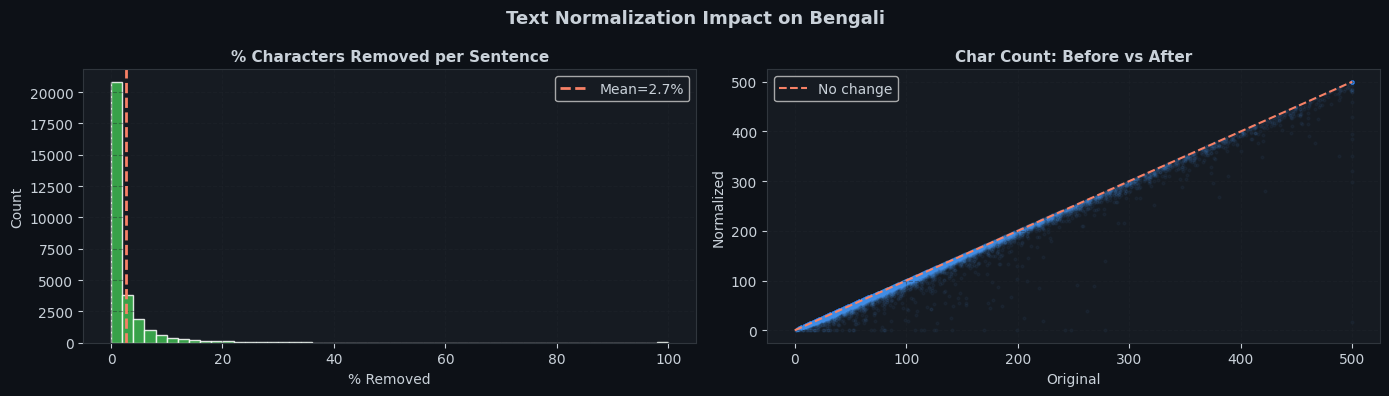

Avg % removed: 2.7%  | Sentences unchanged: 17,512


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Text Normalization Impact on Bengali", fontsize=13, fontweight='bold')

axes[0].hist(removed_pct, bins=50, color=P[2], alpha=0.85, edgecolor='white', lw=0.3)
axes[0].axvline(removed_pct.mean(), color=P[1], ls='--', lw=2,
                label=f'Mean={removed_pct.mean():.1f}%')
axes[0].set_title("% Characters Removed per Sentence", fontsize=11, fontweight='bold')
axes[0].set_xlabel("% Removed"); axes[0].set_ylabel("Count"); axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].scatter(df['char_count'].clip(0,500), df['norm_char'].clip(0,500),
                alpha=0.04, s=4, color=P[0])
axes[1].plot([0,500],[0,500], color=P[1], ls='--', lw=1.5, label='No change')
axes[1].set_title("Char Count: Before vs After", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Original"); axes[1].set_ylabel("Normalized")
axes[1].legend(); axes[1].grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
print(f"Avg % removed: {removed_pct.mean():.1f}%  | Sentences unchanged: {(removed_pct==0).sum():,}")

---
## Section 3 — Tokenization & Stopword Removal on Bengali


In [11]:
BENGALI_STOPWORDS = set([
    'এই','এ','এর','একটি','একটা','তার','তাদের','তাকে','তারা','তিনি',
    'তাই','কিন্তু','আর','বা','এবং','কি','কে','কেন','না','নাই','নয়',
    'হয়','হবে','করা','করে','করেন','করেছে','করছে','করতে','যে','যা',
    'যার','যেন','যখন','যদি','তখন','তবে','তো','এটা','এটি','সে','সব',
    'আছে','ছিল','থেকে','দিয়ে','নিয়ে','বলে','মতো','মত','কোনো','কোন',
    'আমি','আমার','আমাদের','আপনি','আপনার','তুমি','তোমার','আমরা',
    'আবার','আজ','কাল','এখন','এখানে','সেখানে','একটু','অনেক','বেশি',
    'খুব','খুবই','তাই','কারণ','তবু','যদিও','সত্যি','আসলে','এক',
])

def tokenize_bengali(text):
    return [t for t in str(text).split() if t.strip()]

def remove_stopwords(tokens):
    return [t for t in tokens if t not in BENGALI_STOPWORDS and len(t)>1]

df['tokens']      = df['normalized'].apply(tokenize_bengali)
df['tokens_nosw'] = df['tokens'].apply(remove_stopwords)
df['tok_count']   = df['tokens'].str.len()
df['nosw_count']  = df['tokens_nosw'].str.len()
df['sw_pct']      = ((df['tok_count']-df['nosw_count'])/df['tok_count'].clip(1)*100).round(1)

print("Tokenization Examples:")
print("="*65)
for _, row in df.sample(4, random_state=3).iterrows():
    print(f"  Sentence: {row['sentence'][:60]}")
    print(f"  Tokens  : {row['tokens'][:7]}")
    print(f"  No SW   : {row['tokens_nosw'][:7]}")
    print(f"  SW rm'd : {row['tok_count']-row['nosw_count']} words\n")

Tokenization Examples:
  Sentence: আললাহ আল্লাহ তুমি কই তুমি কি দেখ ওর বাবার কান্না তুমি আর কত 
  Tokens  : ['আললাহ', 'আল্লাহ', 'তুমি', 'কই', 'তুমি', 'কি', 'দেখ']
  No SW   : ['আললাহ', 'আল্লাহ', 'কই', 'দেখ', 'ওর', 'বাবার', 'কান্না']
  SW rm'd : 8 words

  Sentence: তোদের আর কি বলে গালি দিবো তোরা তো এমনিই জারজ সন্তান তোদের কপ
  Tokens  : ['তোদের', 'আর', 'কি', 'বলে', 'গালি', 'দিবো', 'তোরা']
  No SW   : ['তোদের', 'গালি', 'দিবো', 'তোরা', 'এমনিই', 'জারজ', 'সন্তান']
  SW rm'd : 7 words

  Sentence: এই রকম ছেলেকে পেটানো দরকার
  Tokens  : ['এই', 'রকম', 'ছেলেকে', 'পেটানো', 'দরকার']
  No SW   : ['রকম', 'ছেলেকে', 'পেটানো', 'দরকার']
  SW rm'd : 1 words

  Sentence: ইন্ডিয়াতে ধনির বাড়ীতে কত বার হামলা হইচে আরো বেসি কিছু হয় বাড়
  Tokens  : ['ইন্ডিয়াতে', 'ধনির', 'বাড়ীতে', 'কত', 'বার', 'হামলা', 'হইচে']
  No SW   : ['ইন্ডিয়াতে', 'ধনির', 'বাড়ীতে', 'কত', 'বার', 'হামলা', 'হইচে']
  SW rm'd : 4 words



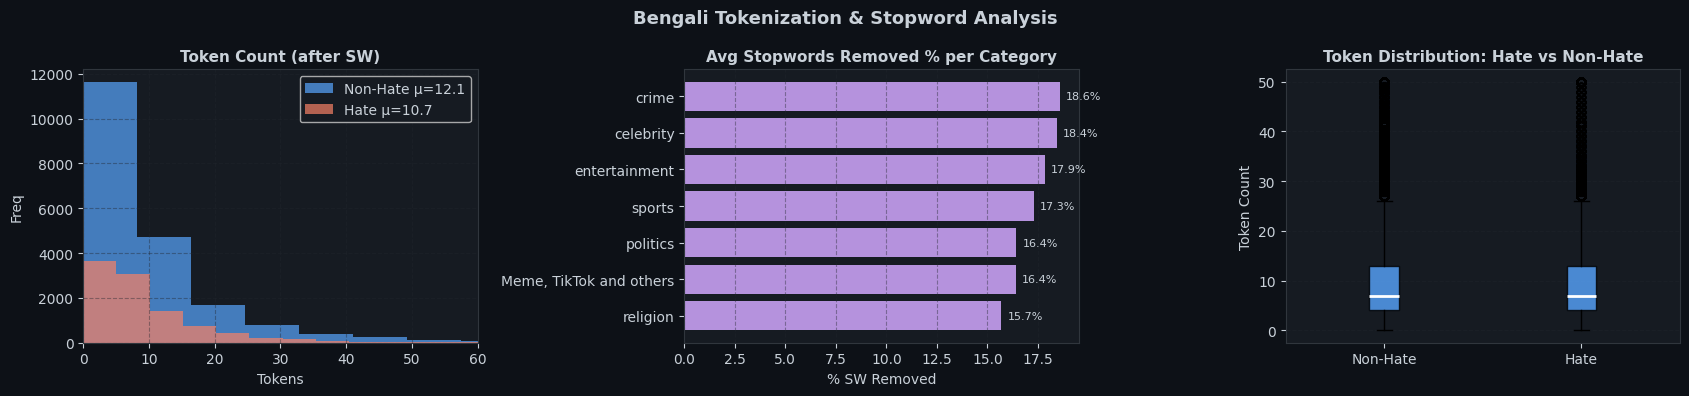

Avg tokens before SW: 14.6  |  After: 11.6


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Bengali Tokenization & Stopword Analysis", fontsize=13, fontweight='bold')

for label,color,name in [(0,P[0],'Non-Hate'),(1,P[1],'Hate')]:
    d = df[df['hate']==label]['nosw_count']
    axes[0].hist(d, bins=50, alpha=0.7, color=color, label=f'{name} μ={d.mean():.1f}')
axes[0].set_xlim(0,60); axes[0].set_title("Token Count (after SW)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Tokens"); axes[0].set_ylabel("Freq"); axes[0].legend(); axes[0].grid(True,alpha=0.4)

sw_cat = df.groupby('category')['sw_pct'].mean().sort_values()
axes[1].barh(sw_cat.index, sw_cat.values, color=P[3], alpha=0.85)
axes[1].set_title("Avg Stopwords Removed % per Category", fontsize=11, fontweight='bold')
axes[1].set_xlabel("% SW Removed"); axes[1].grid(axis='x',alpha=0.4)
for i,v in enumerate(sw_cat.values): axes[1].text(v+0.3,i,f'{v:.1f}%',va='center',fontsize=8)

axes[2].boxplot([df[df['hate']==0]['nosw_count'].clip(0,50),
                 df[df['hate']==1]['nosw_count'].clip(0,50)],
                labels=['Non-Hate','Hate'], patch_artist=True,
                boxprops={'facecolor':P[0],'alpha':0.8},
                medianprops={'color':'white','lw':2})
axes[2].set_title("Token Distribution: Hate vs Non-Hate", fontsize=11, fontweight='bold')
axes[2].set_ylabel("Token Count"); axes[2].grid(axis='y',alpha=0.4)
plt.tight_layout(); plt.show()
print(f"Avg tokens before SW: {df['tok_count'].mean():.1f}  |  After: {df['nosw_count'].mean():.1f}")

---
## Section 4 — Bengali Stemming
Rule-based stemmer strips Bengali verbal & nominal suffixes.


In [13]:
class BengaliStemmer:
    """Rule-based Bengali stemmer — longest match suffix stripping"""
    SUFFIXES = sorted([
        'য়েছিলেন','য়েছিলাম','য়েছিল','য়েছে','য়েছি','তেছেন','তেছিল',
        'েছেন','েছিল','েছে','েছি','েছো','ছিলেন','ছিলাম','ছিলে',
        'ছিল','ছেন','বেন','বে','তেন','তাম','লেন','লাম','লে',
        'দিগকে','দিগের','দেরকে','দের','গুলো','গুলি','গণ',
        'রা','কে','তে','এ','য়','ের','এর','র',
    ], key=len, reverse=True)

    def stem(self, word):
        if len(word) <= 3: return word
        for sfx in self.SUFFIXES:
            if word.endswith(sfx) and len(word)-len(sfx) >= 2:
                return word[:-len(sfx)]
        return word

stemmer = BengaliStemmer()

# Demo
demo_words = [
    ('ছেলেরা','plural noun'),('মেয়েদের','possessive plural'),
    ('খেলছেন','verb formal'),('দৌড়াচ্ছিল','verb past prog'),
    ('বলেছিলেন','verb past perf'),('করতেছেন','verb prog informal'),
    ('মানুষগুলো','noun with article'),('বাচ্চাদের','noun possessive'),
]
print(f"{'Word':<20} {'Stem':<15} Description")
print("─"*50)
for word,desc in demo_words:
    print(f"  {word:<18} {stemmer.stem(word):<15} {desc}")

Word                 Stem            Description
──────────────────────────────────────────────────
  ছেলেরা             ছেলে            plural noun
  মেয়েদের           মেয়ে           possessive plural
  খেলছেন             খেল             verb formal
  দৌড়াচ্ছিল         দৌড়াচ্         verb past prog
  বলেছিলেন           বলে             verb past perf
  করতেছেন            কর              verb prog informal
  মানুষগুলো          মানুষ           noun with article
  বাচ্চাদের          বাচ্চা          noun possessive


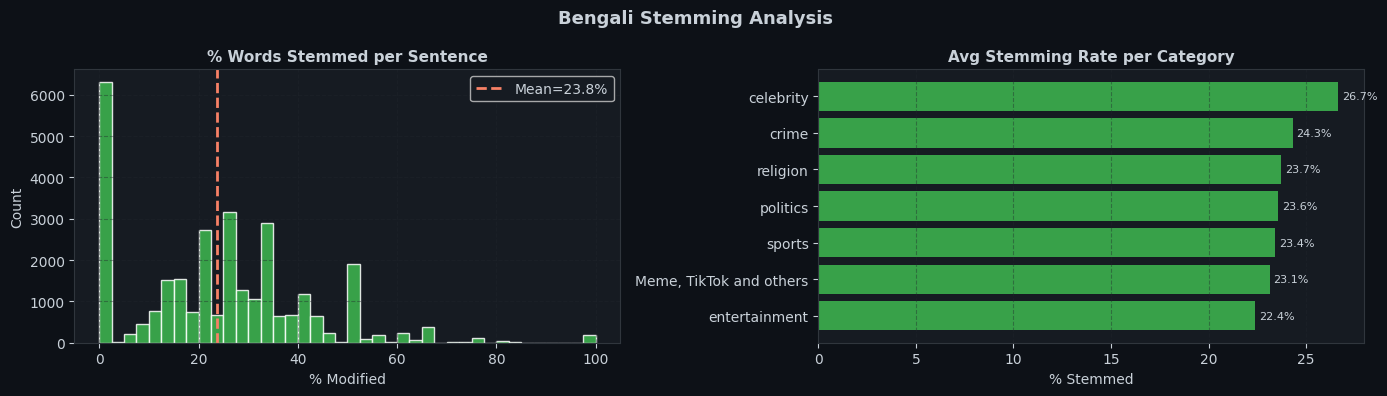

Vocab: Original=47,660  Stemmed=39,791  Reduction=16.5%


In [14]:
df['tokens_stemmed'] = df['tokens_nosw'].apply(lambda toks: [stemmer.stem(t) for t in toks])
df['n_stemmed']      = df.apply(lambda r: sum(o!=s for o,s in zip(r['tokens_nosw'],r['tokens_stemmed'])), axis=1)
df['stem_pct']       = (df['n_stemmed']/df['nosw_count'].clip(1)*100).round(1)

orig_vocab  = set(t for row in df['tokens_nosw']    for t in row)
stem_vocab  = set(t for row in df['tokens_stemmed'] for t in row)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Bengali Stemming Analysis", fontsize=13, fontweight='bold')

axes[0].hist(df['stem_pct'].clip(0,100), bins=40, color=P[2], alpha=0.85, edgecolor='white',lw=0.3)
axes[0].axvline(df['stem_pct'].mean(), color=P[1], ls='--', lw=2, label=f"Mean={df['stem_pct'].mean():.1f}%")
axes[0].set_title("% Words Stemmed per Sentence", fontsize=11, fontweight='bold')
axes[0].set_xlabel("% Modified"); axes[0].set_ylabel("Count"); axes[0].legend(); axes[0].grid(True,alpha=0.4)

sc = df.groupby('category')['stem_pct'].mean().sort_values()
axes[1].barh(sc.index, sc.values, color=P[2], alpha=0.85)
axes[1].set_title("Avg Stemming Rate per Category", fontsize=11, fontweight='bold')
axes[1].set_xlabel("% Stemmed"); axes[1].grid(axis='x',alpha=0.4)
for i,v in enumerate(sc.values): axes[1].text(v+0.2,i,f'{v:.1f}%',va='center',fontsize=8)
plt.tight_layout(); plt.show()
print(f"Vocab: Original={len(orig_vocab):,}  Stemmed={len(stem_vocab):,}  Reduction={1-len(stem_vocab)/len(orig_vocab):.1%}")

---
## Section 5 — Lemmatization & POS-Aware Lemmatization
Dictionary + suffix rules for Bengali morphological analysis.


In [15]:
class BengaliLemmatizer:
    LEXICON = {
        'ছেলেরা':'ছেলে','ছেলেদের':'ছেলে','মেয়েরা':'মেয়ে','মেয়েদের':'মেয়ে',
        'মানুষগুলো':'মানুষ','মানুষদের':'মানুষ','বাচ্চাদের':'বাচ্চা','বাচ্চারা':'বাচ্চা',
        'লোকগুলো':'লোক','লোকেরা':'লোক','লোকদের':'লোক',
        'করেছে':'করা','করছে':'করা','করেছিল':'করা','করবে':'করা','করেন':'করা',
        'বলেছে':'বলা','বলছে':'বলা','বলেছিল':'বলা','বলবে':'বলা',
        'যাচ্ছে':'যাওয়া','গেছে':'যাওয়া','যাবে':'যাওয়া',
        'আসছে':'আসা','এসেছে':'আসা','আসবে':'আসা',
        'দেখছে':'দেখা','দেখেছে':'দেখা','দেখবে':'দেখা',
        'হয়েছে':'হওয়া','হচ্ছে':'হওয়া','হবে':'হওয়া','হয়েছিল':'হওয়া',
        'খাচ্ছে':'খাওয়া','খেয়েছে':'খাওয়া',
        'ভালোভাবে':'ভালো','বড়দের':'বড়','ছোটদের':'ছোট',
    }
    VERB_RULES = [('য়েছিলেন','া'),('য়েছিল','া'),('য়েছে','া'),
                  ('তেছেন','া'),('েছেন','া'),('েছিল','া'),
                  ('েছে','া'),('ছেন','া'),('ছিল','া'),('ছে','া'),
                  ('বেন','া'),('বে','া'),('লেন','া'),('লাম','া')]
    NOUN_RULES = [('দিগকে',''),('দেরকে',''),('দের',''),
                  ('গুলো',''),('গুলি',''),('রা',''),('কে','')]

    def lemmatize(self, word, pos='N'):
        if word in self.LEXICON: return self.LEXICON[word]
        if len(word) <= 2: return word
        rules = self.VERB_RULES if pos=='V' else self.NOUN_RULES
        for sfx, rep in sorted(rules, key=lambda x:-len(x[0])):
            if word.endswith(sfx) and len(word)-len(sfx) >= 2:
                return word[:-len(sfx)] + rep
        return word

lem = BengaliLemmatizer()

def get_pos(word):
    return 'V' if any(word.endswith(e) for e in ('েছে','ছে','বে','লে','তে','েন','ছিল')) else 'N'

df['tokens_lem'] = df['tokens_nosw'].apply(
    lambda toks: [lem.lemmatize(t, get_pos(t)) for t in toks])
df['n_lem'] = df.apply(lambda r: sum(o!=l for o,l in zip(r['tokens_nosw'],r['tokens_lem'])), axis=1)
lem_vocab   = set(t for row in df['tokens_lem'] for t in row)

print("POS-Aware Lemmatization Examples:")
print(f"{'Word':<20} {'POS':<5} {'Lemma'}")
print("─"*40)
for word in ['করেছিল','বলেছেন','যাচ্ছে','ছেলেদের','মানুষদের','বাচ্চারা','লোকগুলো']:
    pos = get_pos(word)
    print(f"  {word:<18} {pos:<5} → {lem.lemmatize(word,pos)}")

POS-Aware Lemmatization Examples:
Word                 POS   Lemma
────────────────────────────────────────
  করেছিল             V     → করা
  বলেছেন             V     → বলা
  যাচ্ছে             V     → যাওয়া
  ছেলেদের            N     → ছেলে
  মানুষদের           N     → মানুষ
  বাচ্চারা           N     → বাচ্চা
  লোকগুলো            N     → লোক


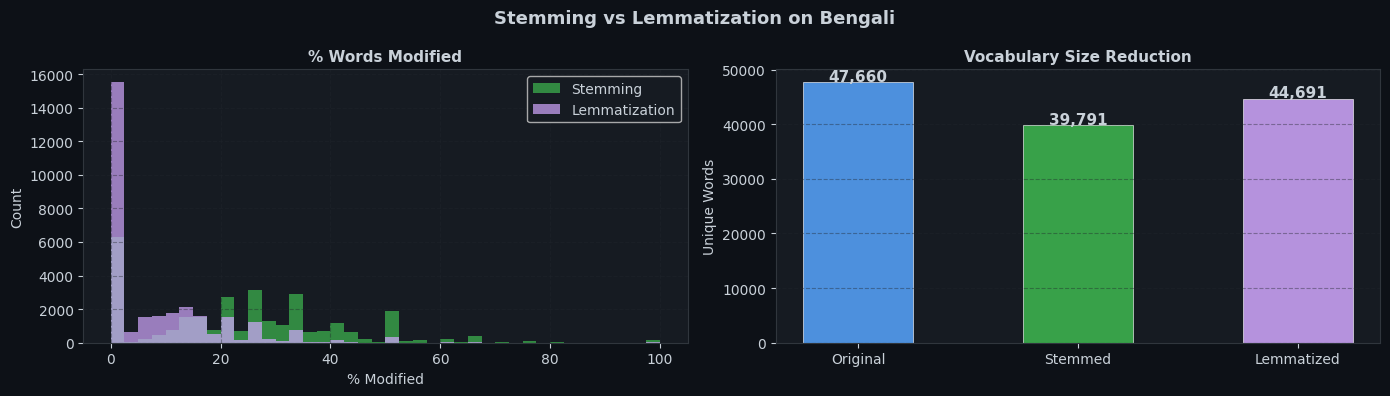

Vocab Reduction — Stem: 16.5%  Lem: 6.2%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
fig.suptitle("Stemming vs Lemmatization on Bengali", fontsize=13, fontweight='bold')

axes[0].hist(df['stem_pct'].clip(0,100), bins=40, alpha=0.7, color=P[2], label='Stemming')
axes[0].hist((df['n_lem']/df['nosw_count'].clip(1)*100).clip(0,100),
             bins=40, alpha=0.7, color=P[3], label='Lemmatization')
axes[0].set_title("% Words Modified", fontsize=11, fontweight='bold')
axes[0].set_xlabel("% Modified"); axes[0].set_ylabel("Count")
axes[0].legend(); axes[0].grid(True,alpha=0.4)

vocab_sizes = {'Original':len(orig_vocab),'Stemmed':len(stem_vocab),'Lemmatized':len(lem_vocab)}
bars = axes[1].bar(vocab_sizes.keys(), vocab_sizes.values(),
                   color=[P[0],P[2],P[3]], edgecolor='white', lw=0.5, alpha=0.85, width=0.5)
for bar,v in zip(bars, vocab_sizes.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title("Vocabulary Size Reduction", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Unique Words"); axes[1].grid(axis='y',alpha=0.4)
plt.tight_layout(); plt.show()
print(f"Vocab Reduction — Stem: {1-len(stem_vocab)/len(orig_vocab):.1%}  Lem: {1-len(lem_vocab)/len(orig_vocab):.1%}")

---
## Section 6 — POS Tagging on Bengali

Rule-based heuristic tagger: N, V, ADJ, ADV, PRON, CONJ, PART


In [17]:
class BengaliPOSTagger:
    PRONOUNS    = {'আমি','আমার','আমাদের','আমরা','তুমি','তোমার','তোমাদের',
                   'সে','তার','তাকে','তারা','তাদের','আপনি','আপনার','আপনারা'}
    CONJUNCTIONS= {'এবং','বা','কিন্তু','তবে','তাই','কারণ','যখন','তখন',
                   'আর','অথবা','যদিও','যেন','তবু','বরং'}
    PARTICLES   = {'না','নাই','নয়','তো','ই','ও','কি','কী','সব','সবাই','কখনো'}
    VERB_SFX    = ('েছে','ছে','বে','লে','তে','েন','ছিল','েছি','চ্ছে','চ্ছিল')
    NOUN_SFX    = ('রা','দের','কে','গুলো','গুলি','তা','তি','ত্ব','নি','নী')
    ADJ_SFX     = ('ময়','বান','শালী','কর','দায়ক','হীন','পূর্ণ','যোগ্য')
    ADV_SFX     = ('ভাবে','ভাবেই','মতো','মত','রূপে','ক্রমে')

    def tag(self, word):
        if word in self.PRONOUNS:     return 'PRON'
        if word in self.CONJUNCTIONS: return 'CONJ'
        if word in self.PARTICLES:    return 'PART'
        if any(word.endswith(s) for s in self.VERB_SFX): return 'V'
        if any(word.endswith(s) for s in self.ADV_SFX):  return 'ADV'
        if any(word.endswith(s) for s in self.ADJ_SFX):  return 'ADJ'
        if any(word.endswith(s) for s in self.NOUN_SFX): return 'N'
        return 'N'

    def tag_sentence(self, tokens):
        return [(t, self.tag(t)) for t in tokens]

pos_tagger = BengaliPOSTagger()
df['pos_tags'] = df['tokens_nosw'].apply(pos_tagger.tag_sentence)

print("POS Tagging Examples on Bengali:")
print("="*60)
for _, row in df.sample(3, random_state=11).iterrows():
    toks = row['tokens_nosw'][:8]
    tags = pos_tagger.tag_sentence(toks)
    print(f"  Sentence: {row['sentence'][:60]}")
    print(f"  Label   : {'HATE' if row['hate'] else 'NON-HATE'}")
    print(f"  Tags    : {tags}\n")

POS Tagging Examples on Bengali:
  Sentence: হা হা হা।মনে হয় প্রেগনেন্ট।
  Label   : NON-HATE
  Tags    : [('হা', 'N'), ('হা', 'N'), ('হা', 'N'), ('মনে', 'N'), ('হয়', 'N'), ('প্রেগনেন্ট', 'N')]

  Sentence: আমি থেকে আপনার ভিডিও দেখি।ভাই একটা কথা আওয়ামীলীগের দোষ আছে ক
  Label   : NON-HATE
  Tags    : [('ভিডিও', 'N'), ('দেখি', 'N'), ('ভাই', 'N'), ('কথা', 'N'), ('আওয়ামীলীগের', 'N'), ('দোষ', 'N'), ('বিএনপি', 'N'), ('রা', 'N')]

  Sentence: ওই কানকির পোলা গরিপ কি তোর মারে কি মোদ খাইহা চোদছে
  Label   : HATE
  Tags    : [('ওই', 'N'), ('কানকির', 'N'), ('পোলা', 'N'), ('গরিপ', 'N'), ('তোর', 'N'), ('মারে', 'N'), ('মোদ', 'N'), ('খাইহা', 'N')]



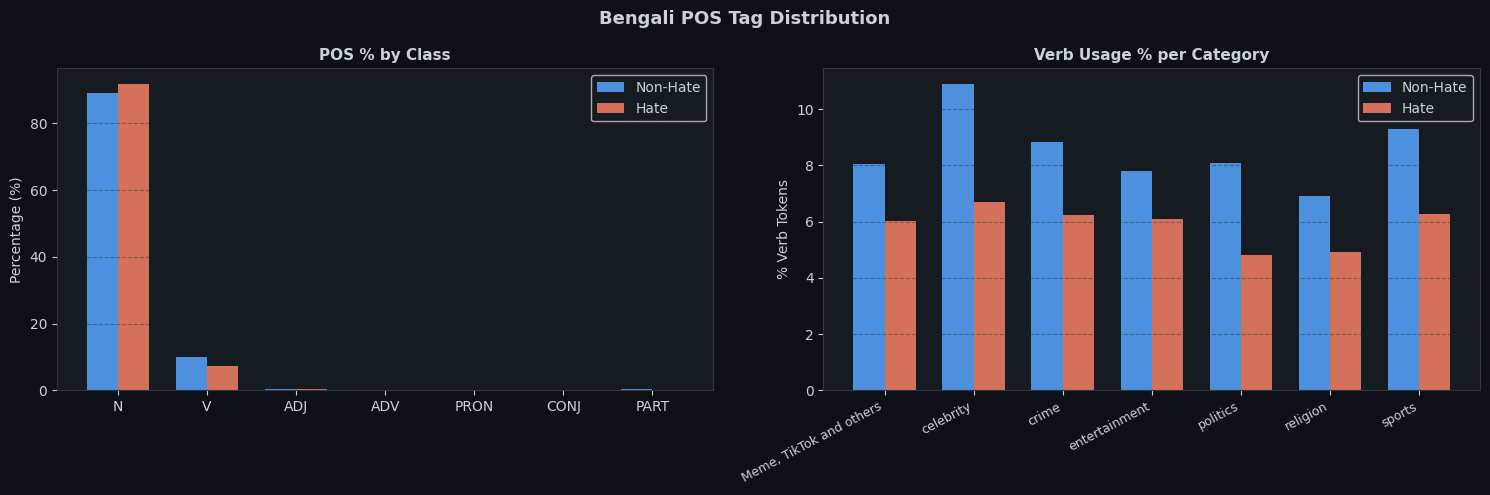

In [18]:
# POS distribution per class
ALL_TAGS = ['N','V','ADJ','ADV','PRON','CONJ','PART']
hate_tags = Counter(t for row,h in zip(df['pos_tags'],df['hate']) if h==1 for _,t in row)
nh_tags   = Counter(t for row,h in zip(df['pos_tags'],df['hate']) if h==0 for _,t in row)
h_tot = sum(hate_tags.values()); nh_tot = sum(nh_tags.values())
h_pct  = [hate_tags.get(t,0)/h_tot*100  for t in ALL_TAGS]
nh_pct = [nh_tags.get(t,0)/nh_tot*100   for t in ALL_TAGS]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Bengali POS Tag Distribution", fontsize=13, fontweight='bold')

x = np.arange(len(ALL_TAGS)); w=0.35
axes[0].bar(x-w/2, nh_pct, w, color=P[0], label='Non-Hate', alpha=0.85)
axes[0].bar(x+w/2, h_pct,  w, color=P[1], label='Hate',     alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(ALL_TAGS)
axes[0].set_title("POS % by Class", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Percentage (%)"); axes[0].legend(); axes[0].grid(axis='y',alpha=0.4)

# Verb ratio per category
def verb_ratio(tags): return sum(1 for _,t in tags if t=='V')/max(len(tags),1)*100
df['verb_ratio'] = df['pos_tags'].apply(verb_ratio)
vr = df.groupby(['category','hate'])['verb_ratio'].mean().unstack()
vr.columns = ['Non-Hate','Hate']
x2 = np.arange(len(vr))
axes[1].bar(x2-w/2, vr['Non-Hate'], w, color=P[0], label='Non-Hate', alpha=0.85)
axes[1].bar(x2+w/2, vr['Hate'],     w, color=P[1], label='Hate',     alpha=0.85)
axes[1].set_xticks(x2); axes[1].set_xticklabels(vr.index, rotation=28, ha='right', fontsize=9)
axes[1].set_title("Verb Usage % per Category", fontsize=11, fontweight='bold')
axes[1].set_ylabel("% Verb Tokens"); axes[1].legend(); axes[1].grid(axis='y',alpha=0.4)
plt.tight_layout(); plt.show()

---
## Section 7 — Transformation-Based Tagging (TBT)

TBT learns correction rules from context. Applied to Bengali:  
`"Change N → V if previous word ends in 'কে'"` etc.


TBT Stats (5,000 sentences):
  Sentences corrected  : 852 (17.0%)
  Avg corrections/sent : 0.22

Correction Rules Applied:
  📌 N→V prev ends 'কে'
  📌 V→N next is plural N
  📌 N→ADJ prev is intensifier
  📌 N→ADV adverbial suffix
  📌 V→N after negation 'না'
  📌 N→CONJ conjunction word


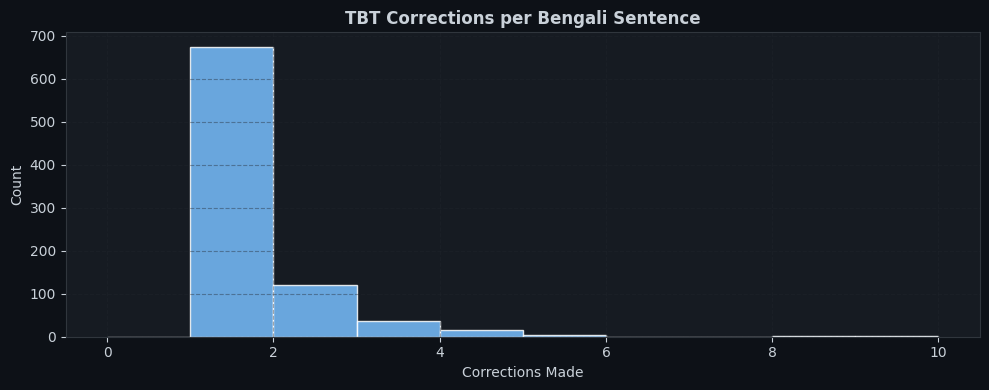

In [19]:
class BengaliTBTagger:
    RULES = [
        (lambda p,c,n: p and p.endswith('কে'),           'N','V',   "N→V prev ends 'কে'"),
        (lambda p,c,n: n and any(n.endswith(s) for s in ('রা','দের','গুলো')), 'V','N', "V→N next is plural N"),
        (lambda p,c,n: p in ('খুব','অনেক','বেশি','অতি'), 'N','ADJ', "N→ADJ prev is intensifier"),
        (lambda p,c,n: c.endswith('ভাবে') or c.endswith('মতো'), 'N','ADV', "N→ADV adverbial suffix"),
        (lambda p,c,n: p and p.endswith('না'),            'V','N',   "V→N after negation 'না'"),
        (lambda p,c,n: c in ('এবং','কিন্তু','তাই','বা'),  'N','CONJ',"N→CONJ conjunction word"),
    ]
    def __init__(self, base): self.base = base

    def tag(self, tokens):
        tags = [self.base.tag(t) for t in tokens]
        for i,(tok,tag) in enumerate(zip(tokens,tags)):
            p = tokens[i-1] if i>0 else None
            n = tokens[i+1] if i<len(tokens)-1 else None
            for fn,from_t,to_t,_ in self.RULES:
                if tags[i]==from_t and fn(p,tok,n):
                    tags[i]=to_t; break
        return list(zip(tokens,tags))

tbt = BengaliTBTagger(pos_tagger)
df['tbt_tags'] = df['tokens_nosw'].apply(tbt.tag)

# Count corrections
changes = pd.Series([
    sum(1 for b,t in zip(base,tbt_r) if b[1]!=t[1])
    for base,tbt_r in zip(df['pos_tags'].head(5000), df['tbt_tags'].head(5000))
])

print(f"TBT Stats (5,000 sentences):")
print(f"  Sentences corrected  : {(changes>0).sum():,} ({(changes>0).mean()*100:.1f}%)")
print(f"  Avg corrections/sent : {changes.mean():.2f}")
print(f"\nCorrection Rules Applied:")
for _,_,_,desc in BengaliTBTagger.RULES: print(f"  📌 {desc}")

fig, ax = plt.subplots(figsize=(10,4))
ax.hist(changes[changes>0], bins=range(0,changes.max()+2), color=P[5], alpha=0.85, edgecolor='white')
ax.set_title("TBT Corrections per Bengali Sentence", fontsize=12, fontweight='bold')
ax.set_xlabel("Corrections Made"); ax.set_ylabel("Count"); ax.grid(True,alpha=0.4)
plt.tight_layout(); plt.show()

---
## Section 8 — One-Hot Encoding on Bengali Vocabulary


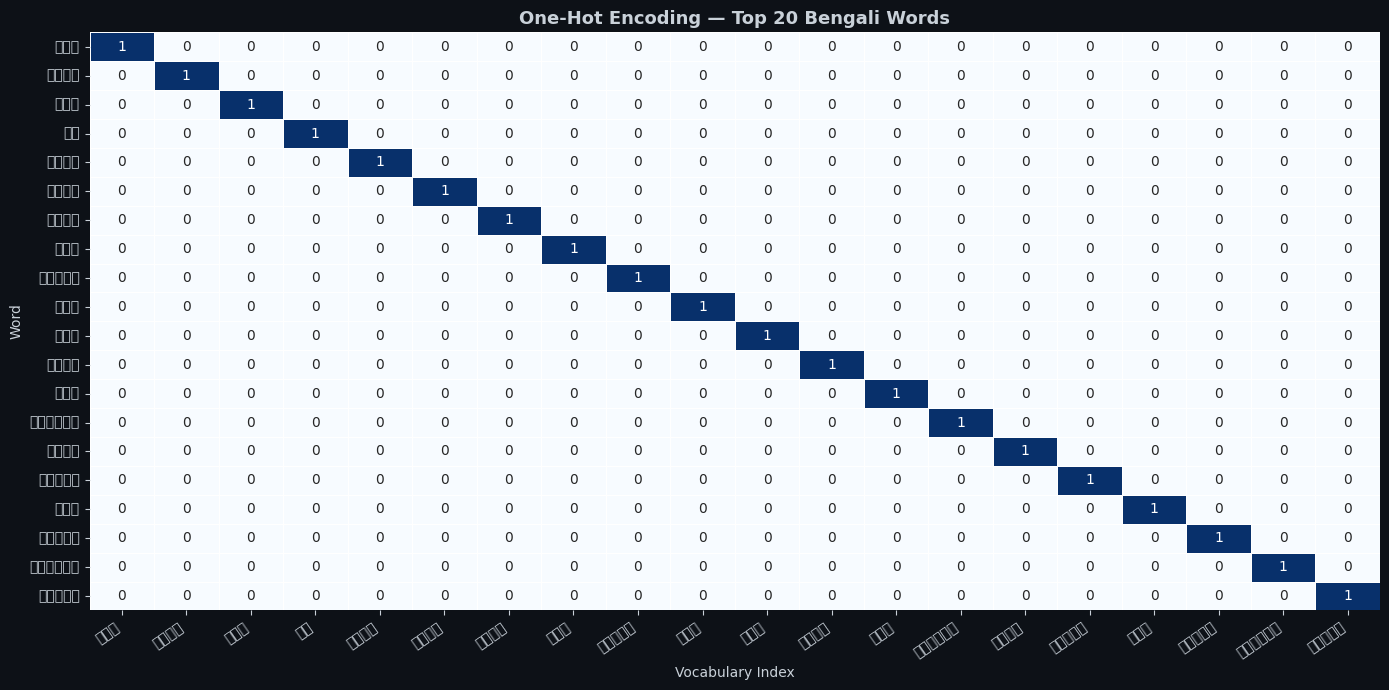

Multi-hot doc matrix: (200, 20)
Avg features per doc: 0.7 / 20


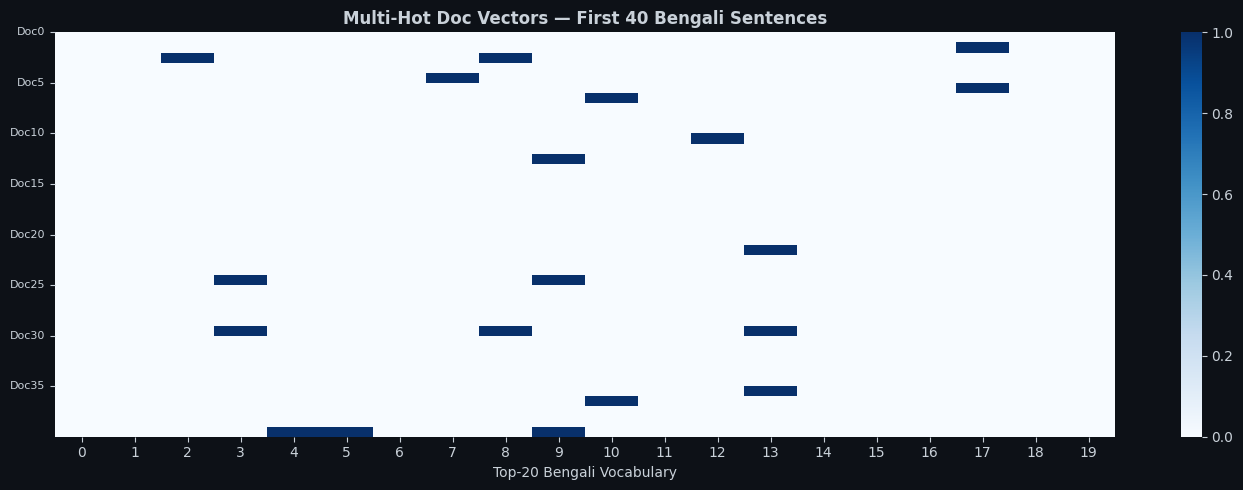

In [20]:
flat_tokens = [t for row in df['tokens_nosw'] for t in row]
top20_words = [w for w,_ in Counter(flat_tokens).most_common(20)]
w2i = {w:i for i,w in enumerate(top20_words)}

def one_hot(word):
    v = np.zeros(20, dtype=int)
    if word in w2i: v[w2i[word]] = 1
    return v

matrix_ohe = np.array([one_hot(w) for w in top20_words])
fig, ax = plt.subplots(figsize=(14,7))
sns.heatmap(matrix_ohe, annot=True, fmt='d', cmap='Blues',
            xticklabels=top20_words, yticklabels=top20_words,
            ax=ax, linewidths=0.4, cbar=False)
ax.set_title("One-Hot Encoding — Top 20 Bengali Words", fontsize=13, fontweight='bold')
ax.set_xlabel("Vocabulary Index"); ax.set_ylabel("Word")
plt.xticks(rotation=35, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# Multi-hot document vectors
def multihot(tokens):
    v = np.zeros(20, dtype=int)
    for t in tokens:
        if t in w2i: v[w2i[t]] = 1
    return v

ohe_docs = np.array([multihot(r) for r in df['tokens_nosw'].head(200)])
print(f"Multi-hot doc matrix: {ohe_docs.shape}")
print(f"Avg features per doc: {ohe_docs.sum(1).mean():.1f} / 20")

fig, ax = plt.subplots(figsize=(14,5))
sns.heatmap(ohe_docs[:40], cmap='Blues', ax=ax,
            yticklabels=[f"{'H' if h else 'N'}" for h in df['hate'].head(40)])
ax.set_title("Multi-Hot Doc Vectors — First 40 Bengali Sentences", fontsize=12, fontweight='bold')
ax.set_xlabel("Top-20 Bengali Vocabulary"); ax.set_yticks(range(0,40,5))
ax.set_yticklabels([f"Doc{i}" for i in range(0,40,5)], fontsize=8)
plt.tight_layout(); plt.show()

---
## Section 9 — Bag of Words on Bengali Corpus


BoW Matrix : (30000, 2142)
Vocabulary : 2,142 Bengali words
Sparsity   : 99.75%


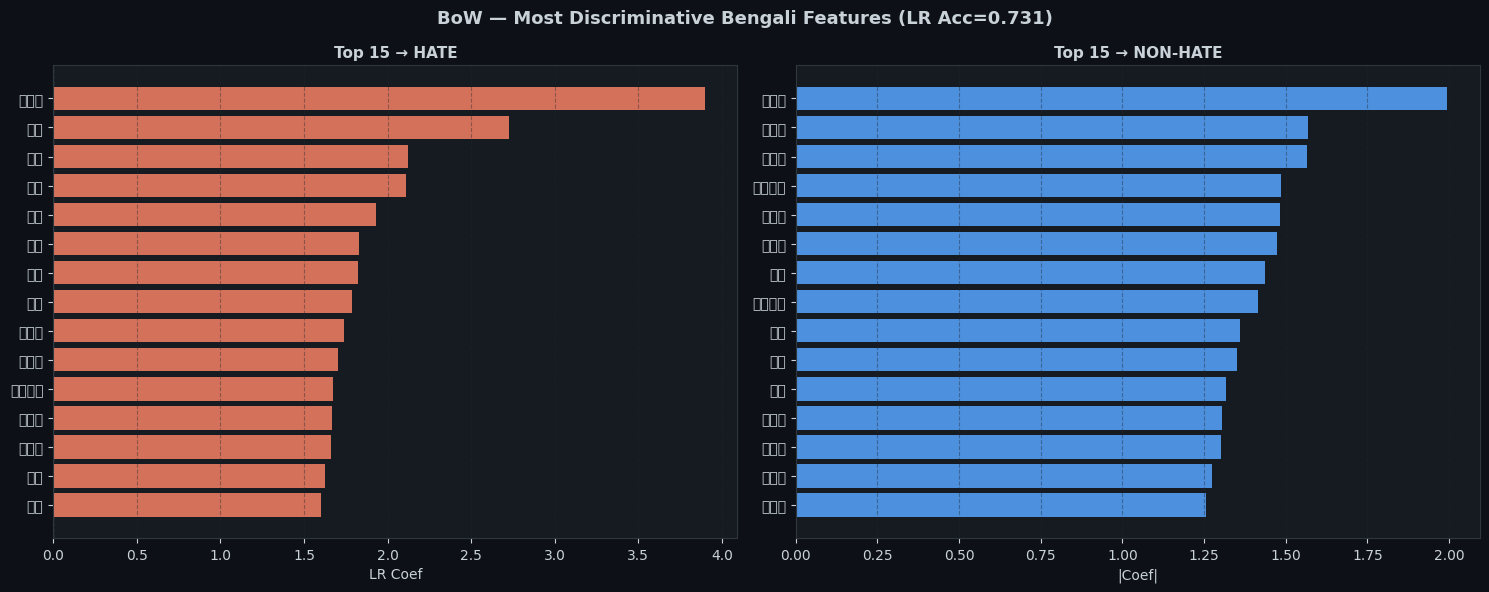

In [21]:
df['text_ml'] = df['tokens_nosw'].apply(lambda t: ' '.join(t))

bow_vec = CountVectorizer(max_features=5000, min_df=3)
X_bow   = bow_vec.fit_transform(df['text_ml'])

print(f"BoW Matrix : {X_bow.shape}")
print(f"Vocabulary : {len(bow_vec.vocabulary_):,} Bengali words")
print(f"Sparsity   : {(1-X_bow.nnz/(X_bow.shape[0]*X_bow.shape[1]))*100:.2f}%")

# LR on BoW to find discriminative features
Xtr_b,Xte_b,ytr_b,yte_b = train_test_split(X_bow, df['hate'],
                            test_size=0.2, stratify=df['hate'], random_state=42)
lr_b = LogisticRegression(max_iter=500, C=1.0, random_state=42)
lr_b.fit(Xtr_b, ytr_b)
acc_bow_lr = accuracy_score(yte_b, lr_b.predict(Xte_b))

feat_bow = bow_vec.get_feature_names_out()
coefs    = lr_b.coef_[0]
top_hate_bow    = [(feat_bow[i],coefs[i]) for i in np.argsort(coefs)[-15:]][::-1]
top_nonhate_bow = [(feat_bow[i],coefs[i]) for i in np.argsort(coefs)[:15]]

fig, axes = plt.subplots(1, 2, figsize=(15,6))
fig.suptitle(f"BoW — Most Discriminative Bengali Features (LR Acc={acc_bow_lr:.3f})",
             fontsize=13, fontweight='bold')
axes[0].barh([x[0] for x in reversed(top_hate_bow)],
             [x[1] for x in reversed(top_hate_bow)], color=P[1], alpha=0.85)
axes[0].set_title("Top 15 → HATE",     fontsize=11, fontweight='bold'); axes[0].set_xlabel("LR Coef")
axes[0].axvline(0, color='white', lw=0.8, ls='--'); axes[0].grid(axis='x',alpha=0.4)

axes[1].barh([x[0] for x in reversed(top_nonhate_bow)],
             [-x[1] for x in reversed(top_nonhate_bow)], color=P[0], alpha=0.85)
axes[1].set_title("Top 15 → NON-HATE", fontsize=11, fontweight='bold'); axes[1].set_xlabel("|Coef|")
axes[1].grid(axis='x',alpha=0.4)
plt.tight_layout(); plt.show()

---
## Section 10 — N-Gram Analysis on Bengali

Bengali bigrams capture abusive multi-word phrases missed by unigrams.


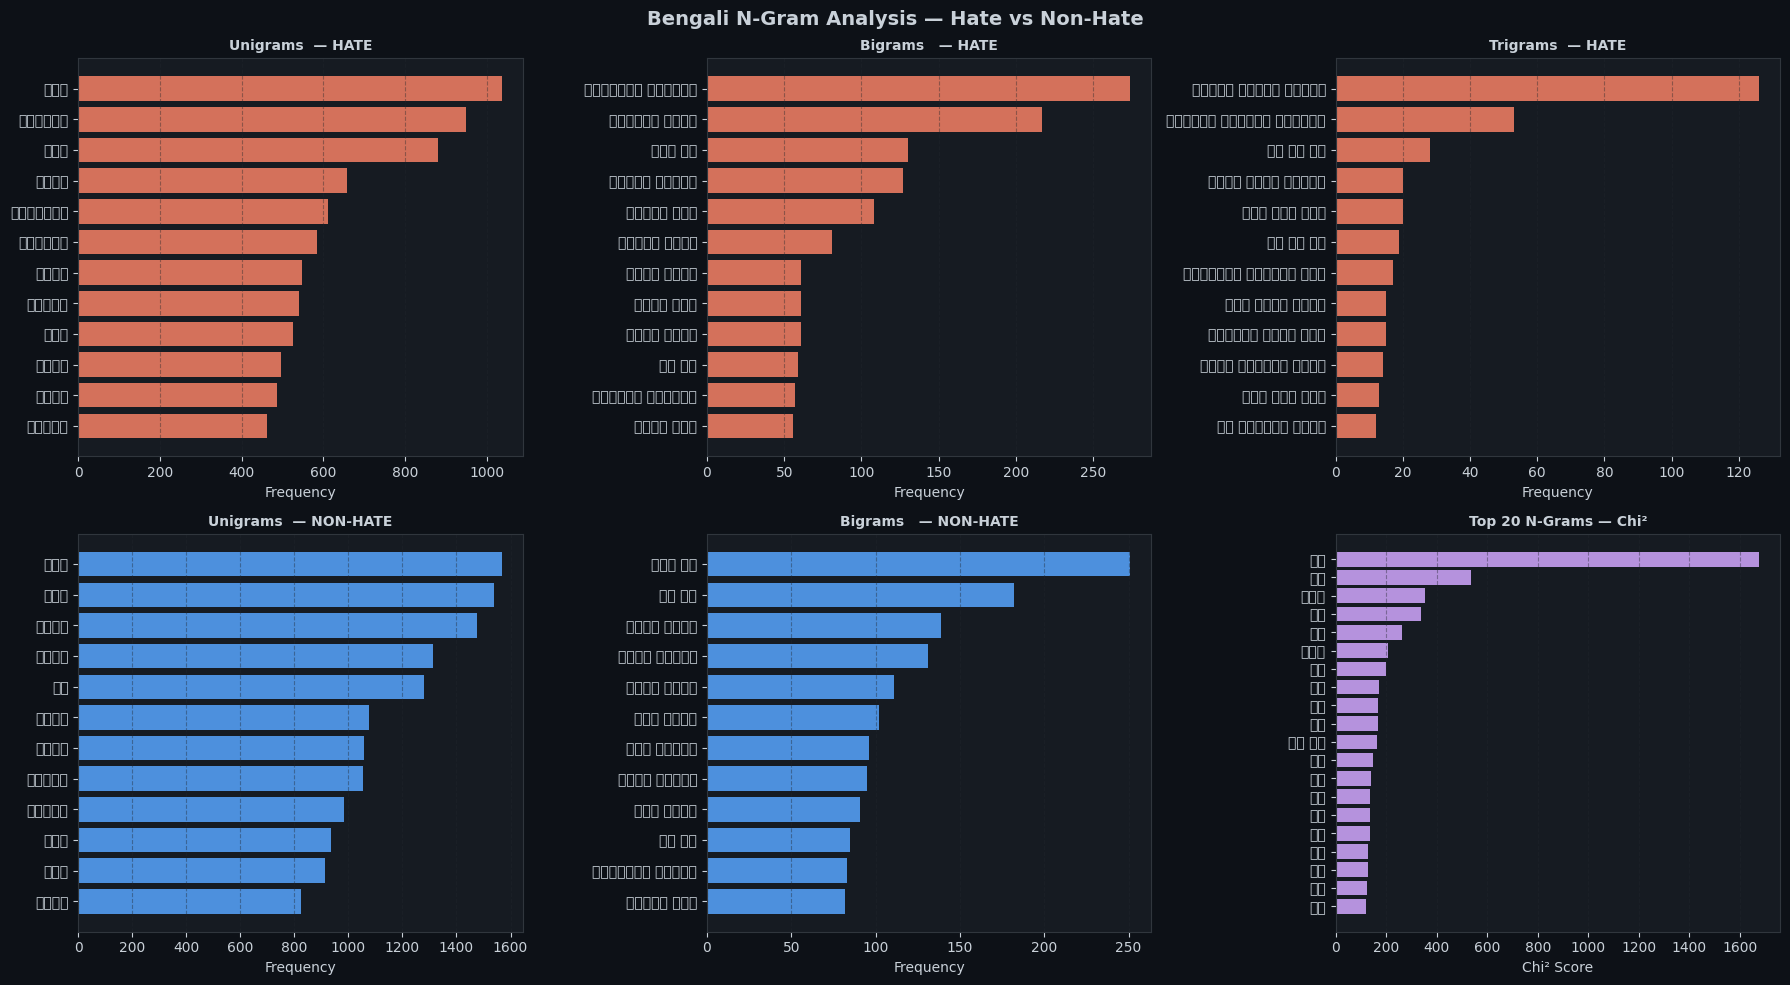

In [22]:
def ngrams(tokens, n):
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

h_uni  = Counter(g for r,h in zip(df['tokens_nosw'],df['hate']) if h==1 for g in r)
h_bi   = Counter(g for r,h in zip(df['tokens_nosw'],df['hate']) if h==1 for g in ngrams(r,2))
h_tri  = Counter(g for r,h in zip(df['tokens_nosw'],df['hate']) if h==1 for g in ngrams(r,3))
nh_uni = Counter(g for r,h in zip(df['tokens_nosw'],df['hate']) if h==0 for g in r)
nh_bi  = Counter(g for r,h in zip(df['tokens_nosw'],df['hate']) if h==0 for g in ngrams(r,2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Bengali N-Gram Analysis — Hate vs Non-Hate", fontsize=14, fontweight='bold')

for ax,(counter,title,color) in zip(axes.flatten(), [
    (h_uni,  "Unigrams  — HATE",     P[1]),
    (h_bi,   "Bigrams   — HATE",     P[1]),
    (h_tri,  "Trigrams  — HATE",     P[1]),
    (nh_uni, "Unigrams  — NON-HATE", P[0]),
    (nh_bi,  "Bigrams   — NON-HATE", P[0]),
    ({},     "",                     P[2]),
]):
    if not counter: continue
    top = counter.most_common(12)
    ax.barh([t[0] for t in reversed(top)],[t[1] for t in reversed(top)],color=color,alpha=0.85)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Frequency"); ax.grid(axis='x',alpha=0.4)

# Chi-squared top n-grams
ng_vec = CountVectorizer(ngram_range=(1,3), max_features=10000, min_df=3)
X_ng   = ng_vec.fit_transform(df['text_ml'])
chi2_s, _ = chi2(X_ng, df['hate'])
feat_ng = ng_vec.get_feature_names_out()
top_chi = [(feat_ng[i],chi2_s[i]) for i in np.argsort(chi2_s)[-20:]][::-1]
axes[1,2].barh([x[0] for x in reversed(top_chi)],
               [x[1] for x in reversed(top_chi)], color=P[3], alpha=0.85)
axes[1,2].set_title("Top 20 N-Grams — Chi²", fontsize=10, fontweight='bold')
axes[1,2].set_xlabel("Chi² Score"); axes[1,2].grid(axis='x',alpha=0.4)
plt.tight_layout(); plt.show()

---
## Section 11 — TF-IDF on Bengali

**Char TF-IDF** (2-4 grams) is language-agnostic and works natively on Bengali script.


Word TF-IDF : (30000, 13382)  nnz=240,162
Char TF-IDF : (30000, 50000)  nnz=4,562,198


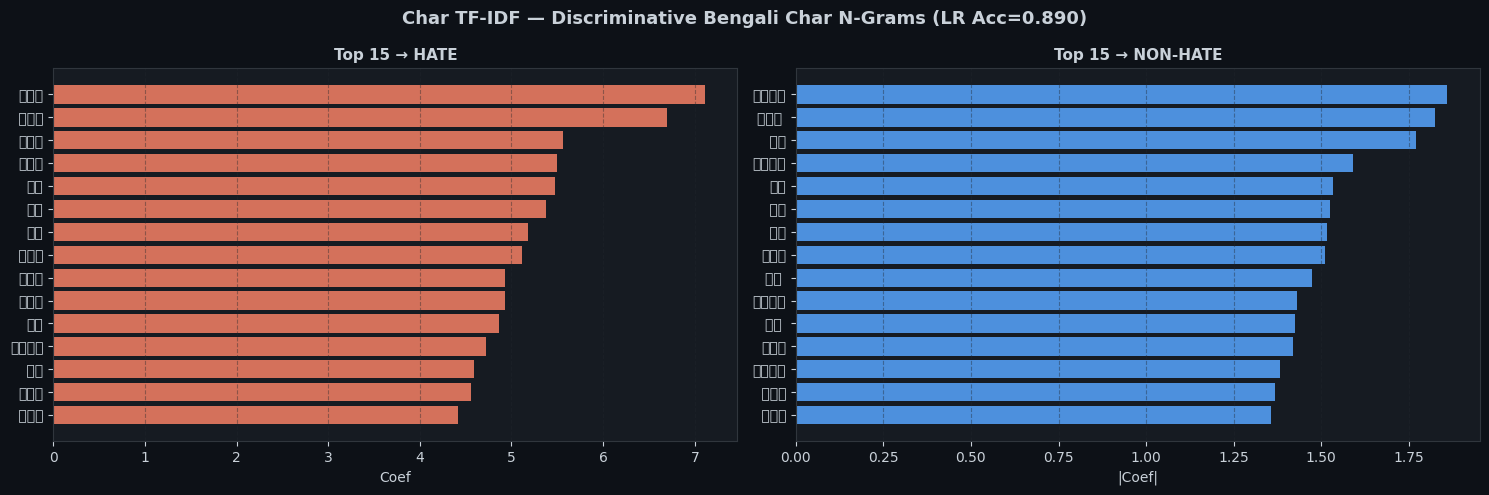

In [23]:
# Word TF-IDF
tfidf_word = TfidfVectorizer(ngram_range=(1,2), max_features=30000,
                              min_df=3, sublinear_tf=True)
X_tfidf_word = tfidf_word.fit_transform(df['text_ml'])

# Char TF-IDF (best for Bengali)
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4),
                              max_features=50000, sublinear_tf=True)
X_tfidf_char = tfidf_char.fit_transform(df['sentence'].astype(str))

print(f"Word TF-IDF : {X_tfidf_word.shape}  nnz={X_tfidf_word.nnz:,}")
print(f"Char TF-IDF : {X_tfidf_char.shape}  nnz={X_tfidf_char.nnz:,}")

# LR on char TF-IDF for discriminative features
Xtr,Xte,ytr,yte = train_test_split(X_tfidf_char, df['hate'],
                   test_size=0.2, stratify=df['hate'], random_state=42)
lr_c = LogisticRegression(max_iter=1000, C=1.5, random_state=42)
lr_c.fit(Xtr, ytr)
acc_tfidf = accuracy_score(yte, lr_c.predict(Xte))

coefs_c = lr_c.coef_[0]; feat_c = tfidf_char.get_feature_names_out()
top_h_c  = [(feat_c[i],coefs_c[i]) for i in np.argsort(coefs_c)[-15:]][::-1]
top_nh_c = [(feat_c[i],coefs_c[i]) for i in np.argsort(coefs_c)[:15]]

fig, axes = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle(f"Char TF-IDF — Discriminative Bengali Char N-Grams (LR Acc={acc_tfidf:.3f})",
             fontsize=13, fontweight='bold')
axes[0].barh([x[0] for x in reversed(top_h_c)],[x[1] for x in reversed(top_h_c)],color=P[1],alpha=0.85)
axes[0].set_title("Top 15 → HATE",fontsize=11,fontweight='bold'); axes[0].set_xlabel("Coef"); axes[0].grid(axis='x',alpha=0.4)
axes[1].barh([x[0] for x in reversed(top_nh_c)],[-x[1] for x in reversed(top_nh_c)],color=P[0],alpha=0.85)
axes[1].set_title("Top 15 → NON-HATE",fontsize=11,fontweight='bold'); axes[1].set_xlabel("|Coef|"); axes[1].grid(axis='x',alpha=0.4)
plt.tight_layout(); plt.show()

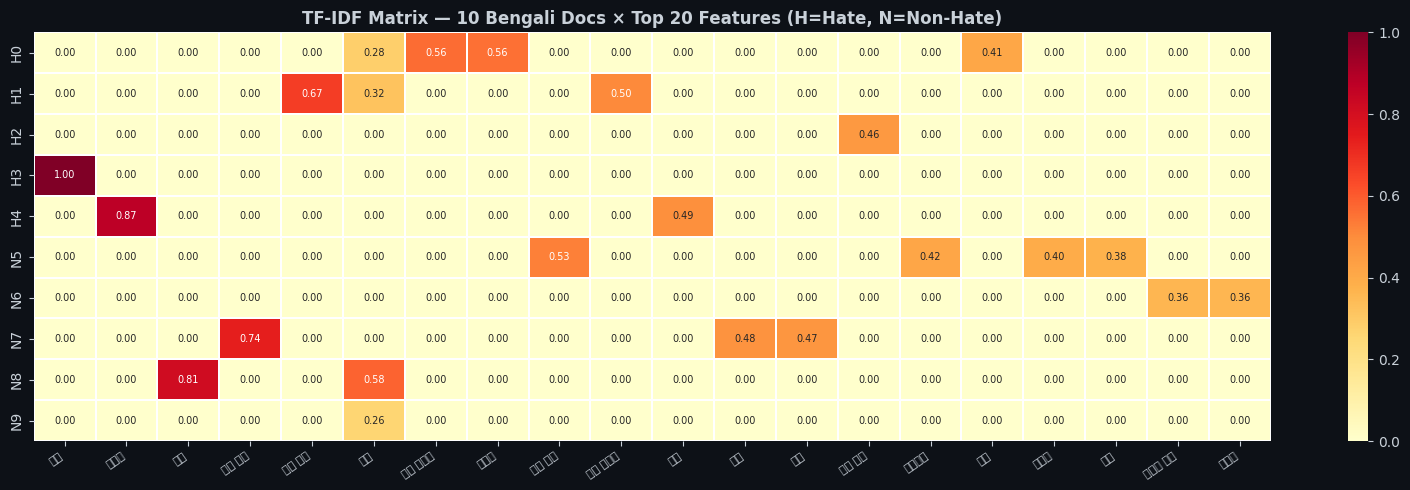

In [24]:
sample_docs = pd.concat([df[df['hate']==1].head(5), df[df['hate']==0].head(5)])
X_s = tfidf_word.transform(sample_docs['text_ml'])
fvar = np.asarray(X_s.toarray().var(axis=0)).flatten()
top20f = np.argsort(fvar)[-20:][::-1]
feat20 = tfidf_word.get_feature_names_out()[top20f]
tdf = pd.DataFrame(np.round(X_s[:,top20f].toarray(),3), columns=feat20,
                   index=[f"H{i}" if h else f"N{i}" for i,(h,_) in enumerate(zip(sample_docs['hate'],range(10)))])
fig, ax = plt.subplots(figsize=(16,5))
sns.heatmap(tdf, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.3, annot_kws={'size':7})
ax.set_title("TF-IDF Matrix — 10 Bengali Docs × Top 20 Features (H=Hate, N=Non-Hate)",
             fontsize=12, fontweight='bold')
plt.xticks(rotation=35,ha='right',fontsize=8); plt.tight_layout(); plt.show()

---
## Section 12 — Latent Semantic Analysis on Bengali


LSA: (30000, 50)  |  Explained var: 17.5%


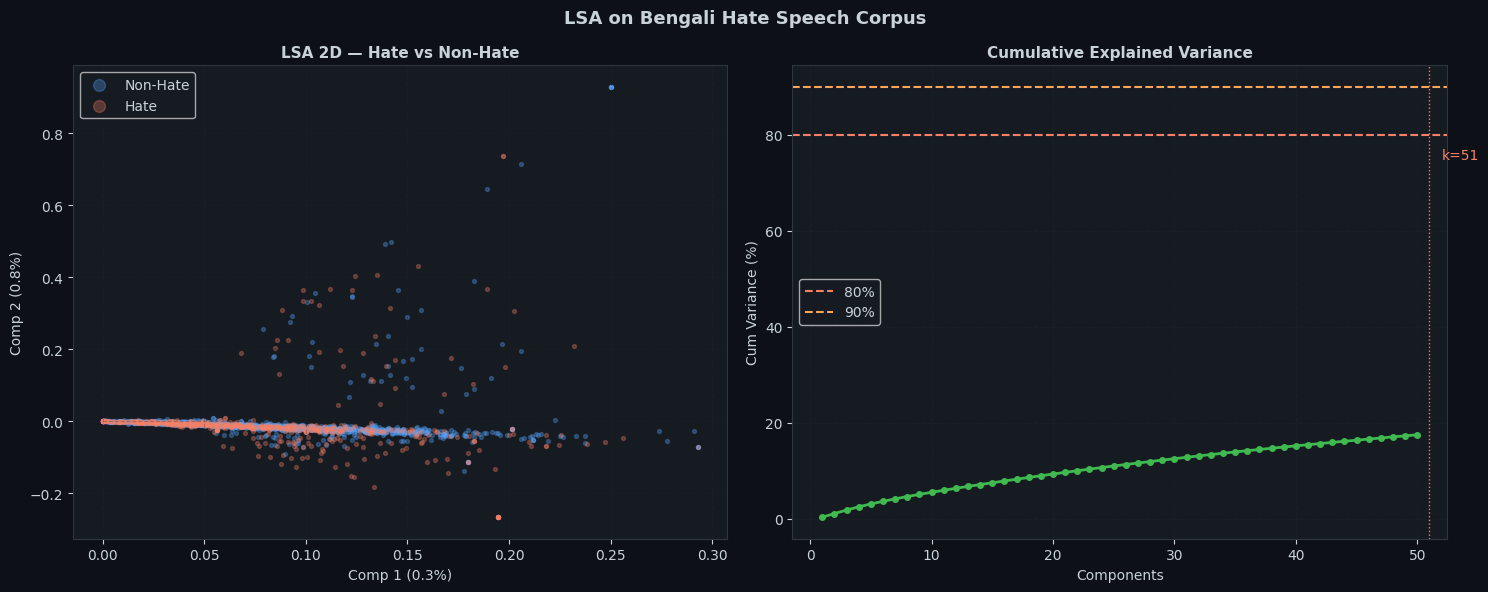

In [25]:
svd50 = TruncatedSVD(n_components=50, random_state=42)
X_lsa = svd50.fit_transform(X_tfidf_word)
X_lsa_norm = normalize(X_lsa, norm='l2')
print(f"LSA: {X_lsa.shape}  |  Explained var: {svd50.explained_variance_ratio_.sum()*100:.1f}%")

svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd2.fit_transform(X_tfidf_word)

fig, axes = plt.subplots(1, 2, figsize=(15,6))
fig.suptitle("LSA on Bengali Hate Speech Corpus", fontsize=13, fontweight='bold')

n_sample = 2000
idx = np.random.RandomState(42).choice(len(X_2d), n_sample, replace=False)
for label,color,name in [(0,P[0],'Non-Hate'),(1,P[1],'Hate')]:
    mask = df['hate'].values[idx]==label
    axes[0].scatter(X_2d[idx[mask],0], X_2d[idx[mask],1], c=color, alpha=0.3, s=8, label=name)
axes[0].set_title("LSA 2D — Hate vs Non-Hate", fontsize=11, fontweight='bold')
axes[0].set_xlabel(f"Comp 1 ({svd2.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"Comp 2 ({svd2.explained_variance_ratio_[1]:.1%})")
axes[0].legend(markerscale=3); axes[0].grid(True,alpha=0.3)

cum = np.cumsum(svd50.explained_variance_ratio_)*100
axes[1].plot(range(1,51), cum, 'o-', color=P[2], lw=2, ms=4)
axes[1].axhline(80, color=P[1], ls='--', lw=1.5, label='80%')
axes[1].axhline(90, color=P[4], ls='--', lw=1.5, label='90%')
k80 = int(np.searchsorted(cum, 80))
axes[1].axvline(k80+1, color=P[1], ls=':', lw=1)
axes[1].text(k80+2, 75, f'k={k80+1}', color=P[1], fontsize=10)
axes[1].set_title("Cumulative Explained Variance", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Components"); axes[1].set_ylabel("Cum Variance (%)")
axes[1].legend(); axes[1].grid(True,alpha=0.4)
plt.tight_layout(); plt.show()

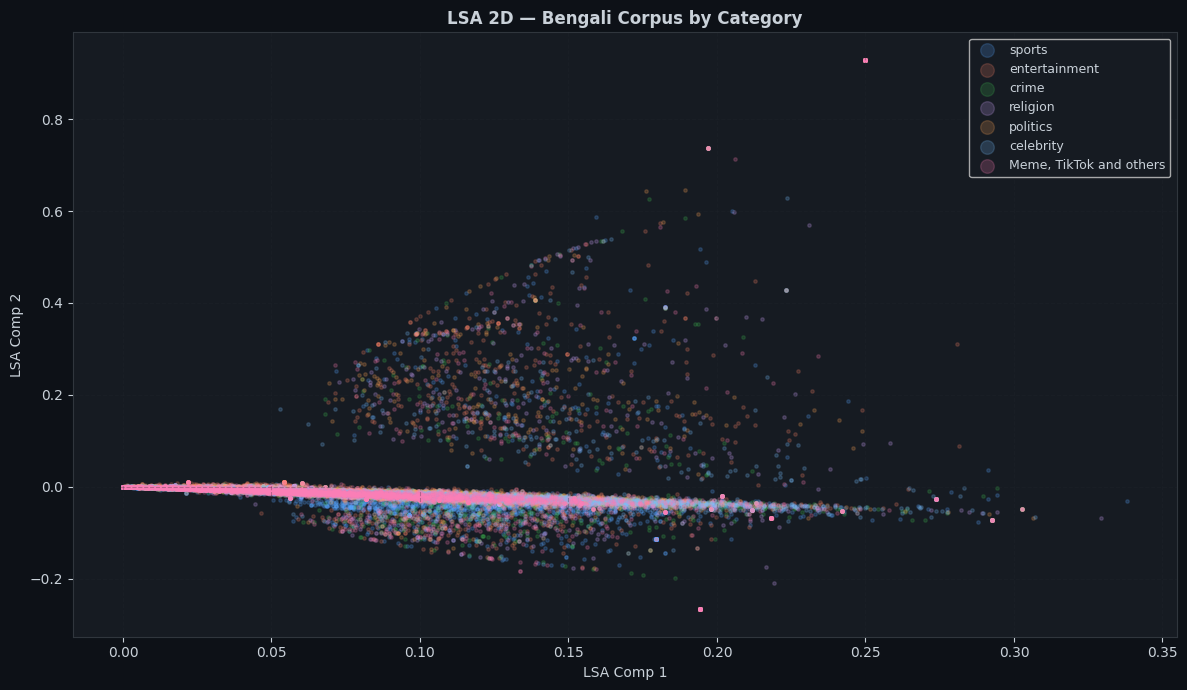

In [26]:
# LSA by category
fig, ax = plt.subplots(figsize=(12,7))
cat_colors = dict(zip(df['category'].unique(), P))
for cat in df['category'].unique():
    mask = df['category'].values==cat
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=cat_colors[cat], alpha=0.2, s=6, label=cat)
ax.set_title("LSA 2D — Bengali Corpus by Category", fontsize=12, fontweight='bold')
ax.set_xlabel("LSA Comp 1"); ax.set_ylabel("LSA Comp 2")
ax.legend(markerscale=4, fontsize=9); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
## Section 13 — Word2Vec trained on Bengali Corpus

Training Skip-gram Word2Vec directly on 30,000 Bengali sentences.


In [27]:
sentences_w2v = df['tokens_nosw'].tolist()

model_w2v = Word2Vec(
    sentences=sentences_w2v,
    vector_size=100, window=5, min_count=5,
    workers=4, epochs=10, sg=1, seed=42
)
vocab_w2v = list(model_w2v.wv.key_to_index.keys())
print(f" Word2Vec trained on Bengali")
print(f"   Vocab  : {len(vocab_w2v):,} words")
print(f"   Dim    : {model_w2v.vector_size}")
print(f"   Sents  : {len(sentences_w2v):,}")

test_words = [w for w in ['মানুষ','ভালো','খেলা','রাজনীতি','ধর্ম'] if w in model_w2v.wv]
print()
for w in test_words[:4]:
    sims = model_w2v.wv.most_similar(w, topn=5)
    print(f"  Similar to '{w}': {[(s[0],round(s[1],3)) for s in sims]}")

 Word2Vec trained on Bengali
   Vocab  : 8,141 words
   Dim    : 100
   Sents  : 30,000

  Similar to 'মানুষ': [('মানুষকে', 0.594), ('মানুস', 0.541), ('ভাবো', 0.53), ('মানুষের', 0.526), ('তামাশা', 0.525)]
  Similar to 'ভালো': [('বালো', 0.698), ('ভাল', 0.623), ('ভালোই', 0.615), ('দারুন', 0.606), ('ভাইয়ার', 0.604)]
  Similar to 'খেলা': [('ক্রিকেট', 0.723), ('দেখবো', 0.704), ('খেলে', 0.685), ('মাঠে', 0.676), ('ম্যাচ', 0.675)]
  Similar to 'রাজনীতি': [('সহিংসতা', 0.796), ('গনতান্ত্রিক', 0.784), ('উন্নয়ন', 0.768), ('রাজনৈতিক', 0.764), ('গণতন্ত্র', 0.756)]


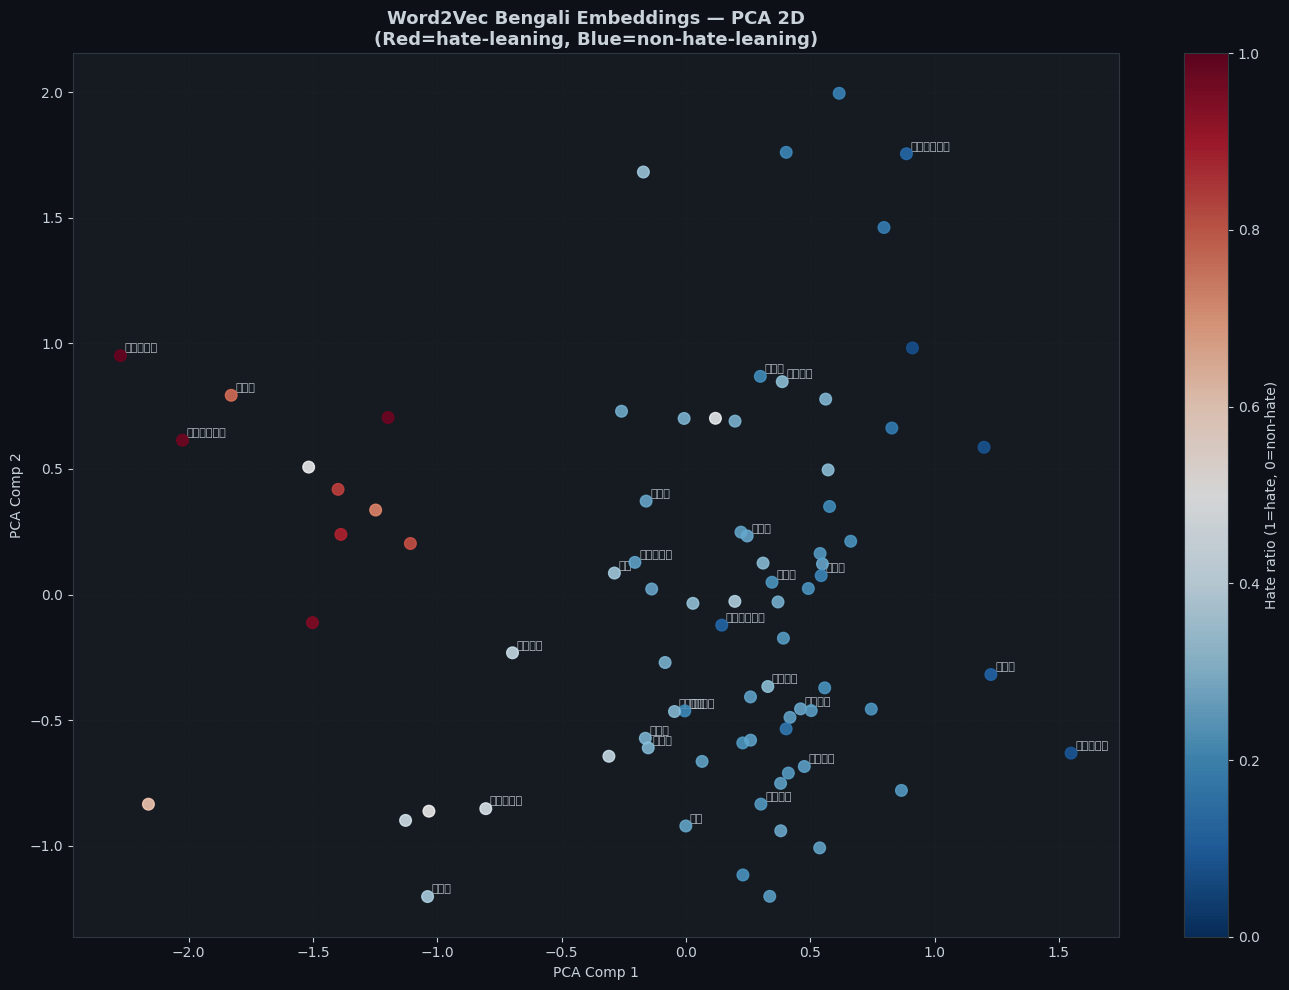

In [28]:
# 2D PCA with hate-ratio coloring
def hate_ratio(word):
    h = h_uni.get(word,0); nh = nh_uni.get(word,0)
    return h/(h+nh) if (h+nh)>0 else 0.5

top80 = [w for w,_ in Counter(flat_tokens).most_common(200) if w in model_w2v.wv][:80]
vecs  = np.array([model_w2v.wv[w] for w in top80])
pca   = PCA(n_components=2, random_state=42)
v2d   = pca.fit_transform(vecs)
ratios = [hate_ratio(w) for w in top80]

fig, ax = plt.subplots(figsize=(14,10))
sc = ax.scatter(v2d[:,0], v2d[:,1], c=ratios, cmap='RdBu_r', s=70,
                zorder=5, vmin=0, vmax=1, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Hate ratio (1=hate, 0=non-hate)')
for i,word in enumerate(top80):
    if i%3==0:
        ax.annotate(word,(v2d[i,0],v2d[i,1]),xytext=(3,3),
                    textcoords='offset points',fontsize=8,color='#c9d1d9',alpha=0.9)
ax.set_title("Word2Vec Bengali Embeddings — PCA 2D\n(Red=hate-leaning, Blue=non-hate-leaning)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("PCA Comp 1"); ax.set_ylabel("PCA Comp 2"); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

Doc embedding matrix: (30000, 100)


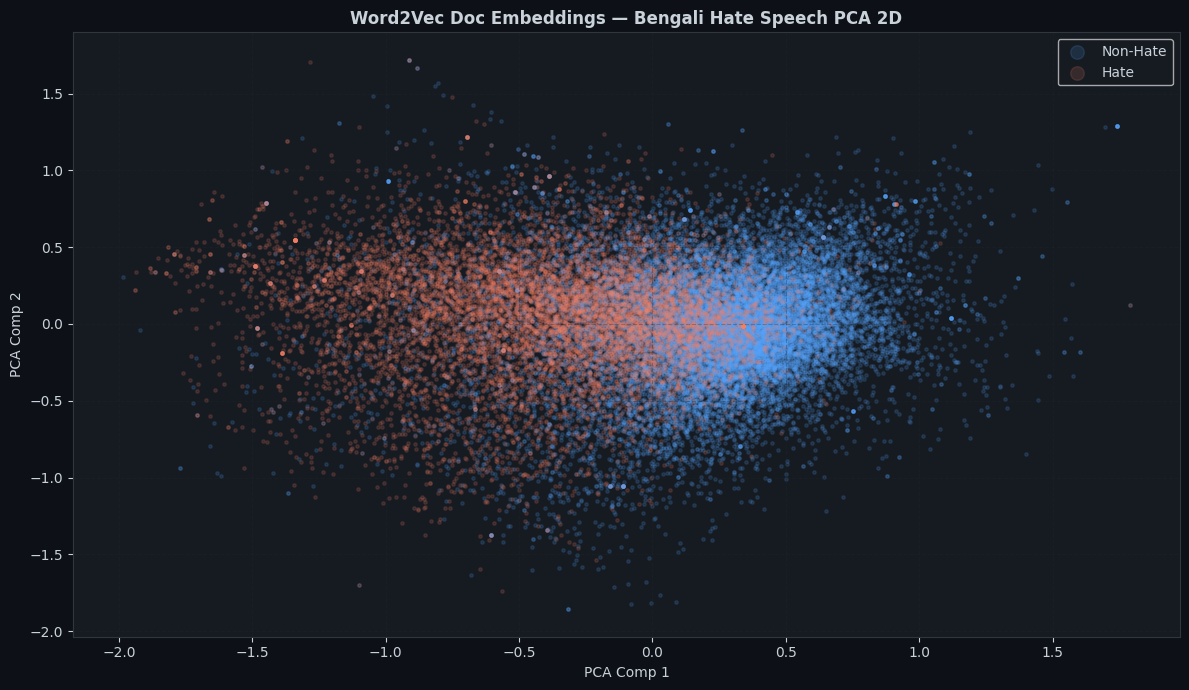

In [29]:
# Document-level Word2Vec for classification
def doc_vec(tokens, model, size=100):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_w2v_doc = np.array([doc_vec(row, model_w2v) for row in df['tokens_nosw']])
print(f"Doc embedding matrix: {X_w2v_doc.shape}")

pca_doc = PCA(n_components=2, random_state=42)
X_doc2d = pca_doc.fit_transform(X_w2v_doc)

fig, ax = plt.subplots(figsize=(12,7))
for label,color,name in [(0,P[0],'Non-Hate'),(1,P[1],'Hate')]:
    mask = df['hate'].values==label
    ax.scatter(X_doc2d[mask,0], X_doc2d[mask,1], c=color, alpha=0.15, s=6, label=name)
ax.set_title("Word2Vec Doc Embeddings — Bengali Hate Speech PCA 2D",
             fontsize=12, fontweight='bold')
ax.set_xlabel("PCA Comp 1"); ax.set_ylabel("PCA Comp 2")
ax.legend(markerscale=4); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
## Section 14 — GloVe Co-occurrence on Bengali

Building a Bengali word co-occurrence matrix and GloVe-style SVD embeddings.


Co-occurrence matrix: (150, 150)
Non-zero entries    : 18,896
Max co-occurrence   : 616.3 ('হা' + 'হা')


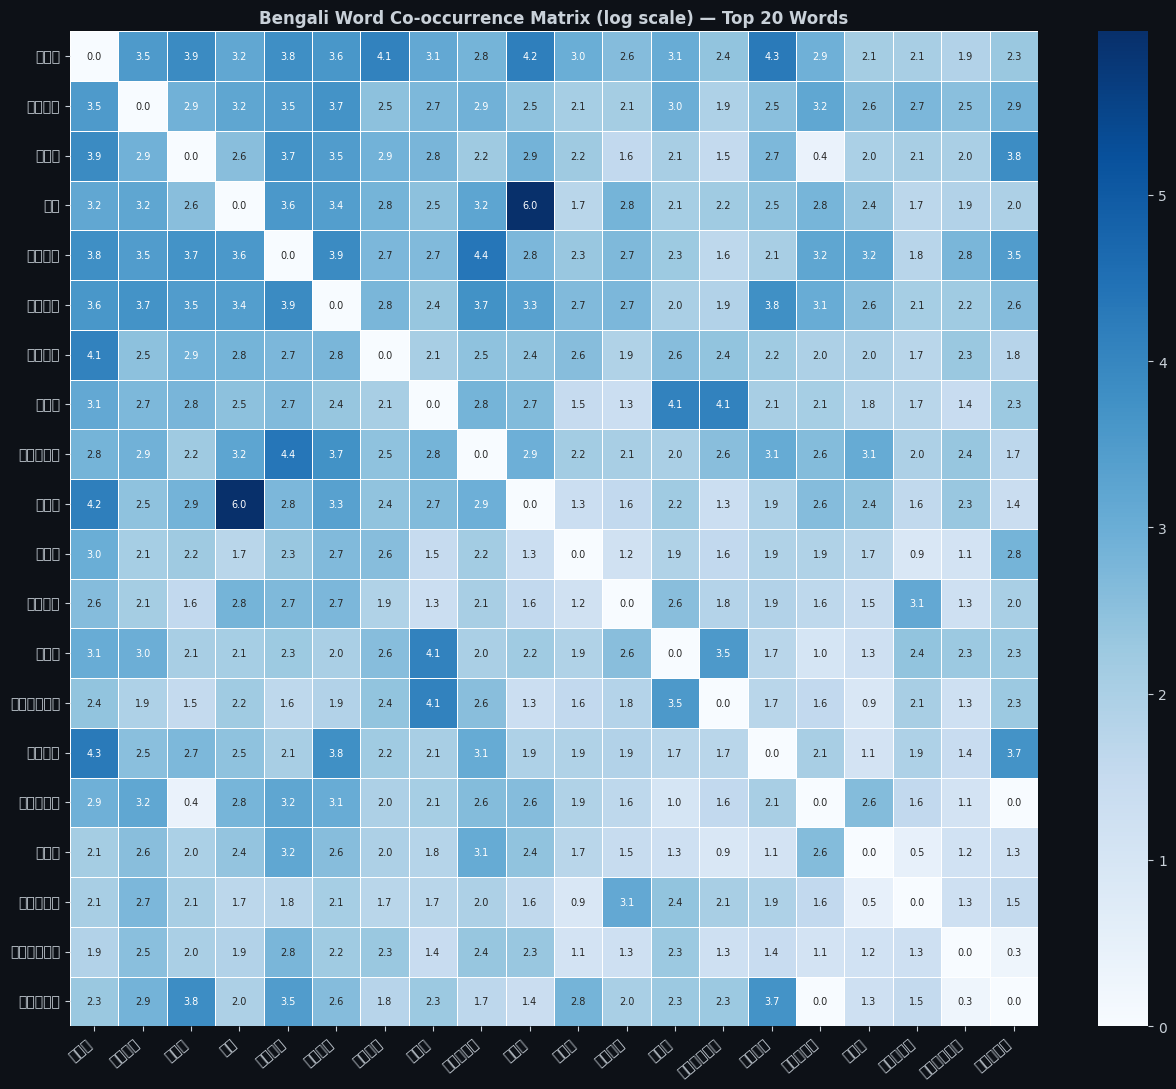

In [30]:
WINDOW=3; VS=150
top_vocab = [w for w,_ in Counter(flat_tokens).most_common(VS)]
w2id = {w:i for i,w in enumerate(top_vocab)}
cooc = np.zeros((VS,VS), dtype=np.float32)
for tokens in df['tokens_nosw']:
    for i,word in enumerate(tokens):
        if word not in w2id: continue
        for j in range(max(0,i-WINDOW), min(len(tokens),i+WINDOW+1)):
            if i==j: continue
            ctx=tokens[j]
            if ctx not in w2id: continue
            cooc[w2id[word],w2id[ctx]] += 1.0/abs(i-j)

print(f"Co-occurrence matrix: {cooc.shape}")
print(f"Non-zero entries    : {(cooc>0).sum():,}")
ai,aj = np.unravel_index(cooc.argmax(), cooc.shape)
print(f"Max co-occurrence   : {cooc.max():.1f} ('{top_vocab[ai]}' + '{top_vocab[aj]}')")

fig, ax = plt.subplots(figsize=(13,11))
top20v = top_vocab[:20]
sub = cooc[:20,:20].copy(); np.fill_diagonal(sub,0)
sns.heatmap(np.log1p(sub), annot=True, fmt='.1f', cmap='Blues',
            xticklabels=top20v, yticklabels=top20v,
            ax=ax, linewidths=0.4, annot_kws={'size':7})
ax.set_title("Bengali Word Co-occurrence Matrix (log scale) — Top 20 Words",
             fontsize=12, fontweight='bold')
plt.xticks(rotation=40,ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

GloVe-style Bengali embeddings: (150, 50)

GloVe cosine similarities:
  sim('ভালো', 'খারাপ') = 0.555
  sim('দেশ', 'বাংলাদেশ') = 0.569


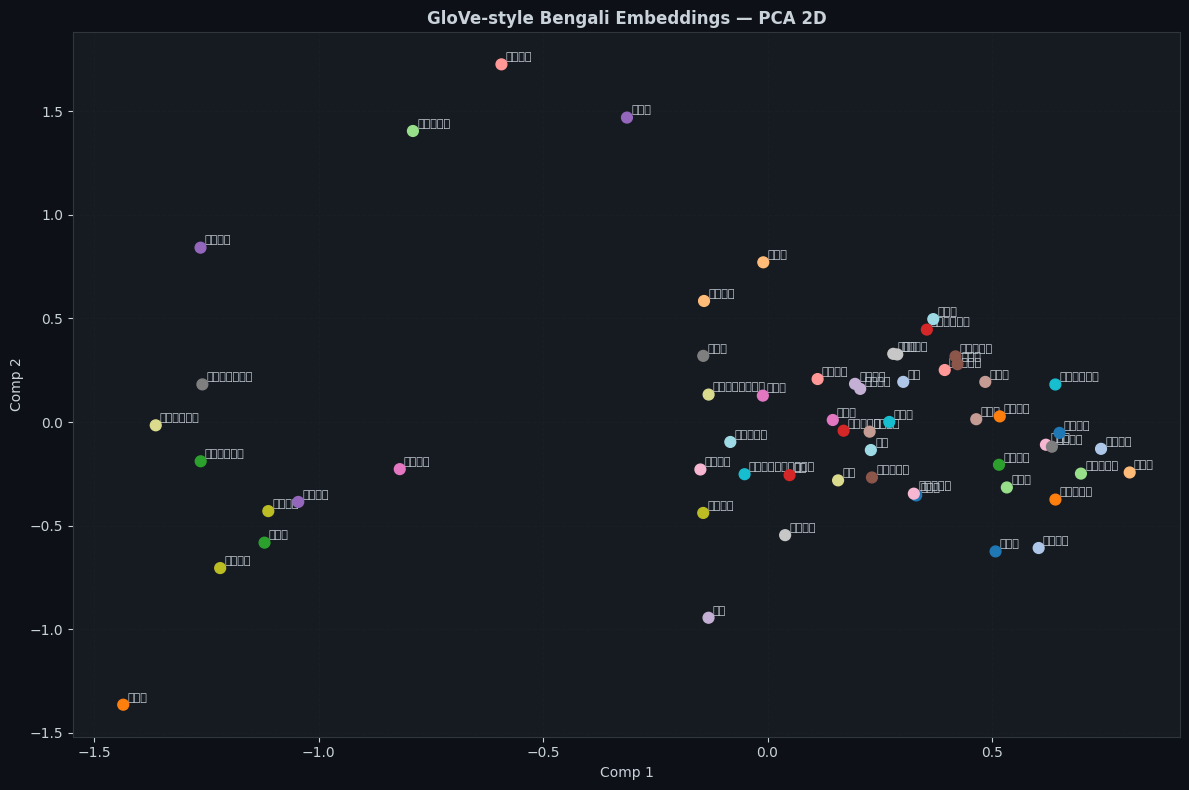

In [31]:
# SVD → GloVe-style embeddings
from numpy.linalg import svd as npsvd
U,S,Vt = npsvd(np.log1p(cooc), full_matrices=False)
DIM=50
glove_vecs = U[:,:DIM]*np.sqrt(S[:DIM])
print(f"GloVe-style Bengali embeddings: {glove_vecs.shape}")

def gsim(w1,w2):
    if w1 not in w2id or w2 not in w2id: return None
    v1=glove_vecs[w2id[w1]]; v2=glove_vecs[w2id[w2]]
    return float(np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2)+1e-8))

pairs=[('মানুষ','মানুষগুলো'),('ভালো','খারাপ'),('দেশ','বাংলাদেশ')]
print("\nGloVe cosine similarities:")
for w1,w2 in pairs:
    s=gsim(w1,w2)
    if s is not None: print(f"  sim('{w1}', '{w2}') = {s:.3f}")

pca_g = __import__('sklearn.decomposition',fromlist=['PCA']).PCA(n_components=2,random_state=42)
g2d = pca_g.fit_transform(glove_vecs[:60])
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(g2d[:,0],g2d[:,1],c=range(60),cmap='tab20',s=60,zorder=5)
for i,w in enumerate(top_vocab[:60]):
    ax.annotate(w,(g2d[i,0],g2d[i,1]),xytext=(3,3),textcoords='offset points',
                fontsize=8,color='#c9d1d9')
ax.set_title("GloVe-style Bengali Embeddings — PCA 2D",fontsize=12,fontweight='bold')
ax.set_xlabel("Comp 1"); ax.set_ylabel("Comp 2"); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
## Section 15 — BERT Fine-tuning for Bengali Hate Speech

**Model:** pretrained Bengali BERT


In [32]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║    BERT Fine-Tuning — Bengali Hate Speech (Complete Code)         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  !pip install transformers torch accelerate datasets               ║
║                                                                    ║
║  from transformers import (AutoTokenizer,                          ║
║      AutoModelForSequenceClassification, TrainingArguments,        ║
║      Trainer)                                                      ║
║  import torch, pandas as pd                                        ║
║  from sklearn.model_selection import train_test_split              ║
║                                                                    ║
║  # 1. Load model                                                   ║
║  MODEL     = "sagorsarker/bangla-bert-base"                        ║
║  tokenizer = AutoTokenizer.from_pretrained(MODEL)                  ║
║  model     = AutoModelForSequenceClassification.from_pretrained(   ║
║                  MODEL, num_labels=2)                              ║
║                                                                    ║
║  # 2. Dataset class                                                ║
║  class HateDS(torch.utils.data.Dataset):                           ║
║      def __init__(self, texts, labels, tok, maxlen=128):           ║
║          self.enc = tok(list(texts), truncation=True,              ║
║                         padding=True, max_length=maxlen,           ║
║                         return_tensors='pt')                       ║
║          self.labels = torch.tensor(list(labels))                  ║
║      def __len__(self): return len(self.labels)                    ║
║      def __getitem__(self, i):                                      ║
║          return {k:v[i] for k,v in self.enc.items()} | {          ║
║                  'labels': self.labels[i]}                         ║
║                                                                    ║
║  # 3. Prepare data                                                 ║
║  df = pd.read_csv("Bengali_hate_speech_.csv")                      ║
║  Xtr,Xte,ytr,yte = train_test_split(df['sentence'],df['hate'],     ║
║      test_size=0.2, stratify=df['hate'], random_state=42)          ║
║  train_ds = HateDS(Xtr, ytr, tokenizer)                            ║
║  test_ds  = HateDS(Xte, yte, tokenizer)                            ║
║                                                                    ║
║  # 4. Training                                                     ║
║  args = TrainingArguments(                                         ║
║      output_dir='./bangla-bert-hate',                              ║
║      num_train_epochs=3,                                           ║
║      per_device_train_batch_size=32,                               ║
║      per_device_eval_batch_size=64,                                ║
║      learning_rate=2e-5, weight_decay=0.01,                        ║
║      warmup_ratio=0.1, fp16=True,                                  ║
║      evaluation_strategy='epoch',                                  ║
║      save_strategy='epoch',                                        ║
║      load_best_model_at_end=True,                                  ║
║  )                                                                 ║
║  trainer = Trainer(model=model, args=args,                         ║
║      train_dataset=train_ds, eval_dataset=test_ds)                 ║
║  trainer.train()                                                   ║
║                                                                    ║
║  # 5. Inference                                                    ║
║  def predict(text):                                                ║
║      inp = tokenizer(text, return_tensors='pt', truncation=True)   ║
║      with torch.no_grad():                                         ║
║          logits = model(**inp).logits                              ║
║      pred = logits.argmax(-1).item()                               ║
║      prob = torch.softmax(logits,-1)[0][pred].item()               ║
║      return ('HATE' if pred==1 else 'NON-HATE'), f'{prob:.1%}'     ║
║                                                                    ║
║  # Expected: ~92-94% accuracy  (vs SVM ~89%)                       ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║    BERT Fine-Tuning — Bengali Hate Speech (Complete Code)         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  !pip install transformers torch accelerate datasets               ║
║                                                                    ║
║  from transformers import (AutoTokenizer,                          ║
║      AutoModelForSequenceClassification, TrainingArguments,        ║
║      Trainer)                                                      ║
║  import torch, pandas as pd                                        ║
║  from sklearn.model_selection import train_test_split              ║
║                                                                    ║
║  # 1. Load model                                                   ║
║  MODEL     = "sagorsarker/bangla-bert-base"                        ║
║  tokeniz

---
## Sections 16–19 — Traditional ML on Bengali

All models use **char TF-IDF (2–4 grams)** — language-agnostic, works natively on Bengali.


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf_char, df['hate'], test_size=0.2, stratify=df['hate'], random_state=42)
y_tr = y_train.values; y_te = y_test.values
print(f"Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"Hate in train: {y_train.sum():,} ({y_train.mean()*100:.1f}%)  Test: {y_test.sum():,}")

Train: 24,000  Test: 6,000
Hate in train: 8,000 (33.3%)  Test: 2,000


Naive Bayes Accuracy: 0.8407

              precision    recall  f1-score   support

    Non-Hate       0.91      0.84      0.88      4000
        Hate       0.73      0.83      0.78      2000

    accuracy                           0.84      6000
   macro avg       0.82      0.84      0.83      6000
weighted avg       0.85      0.84      0.84      6000



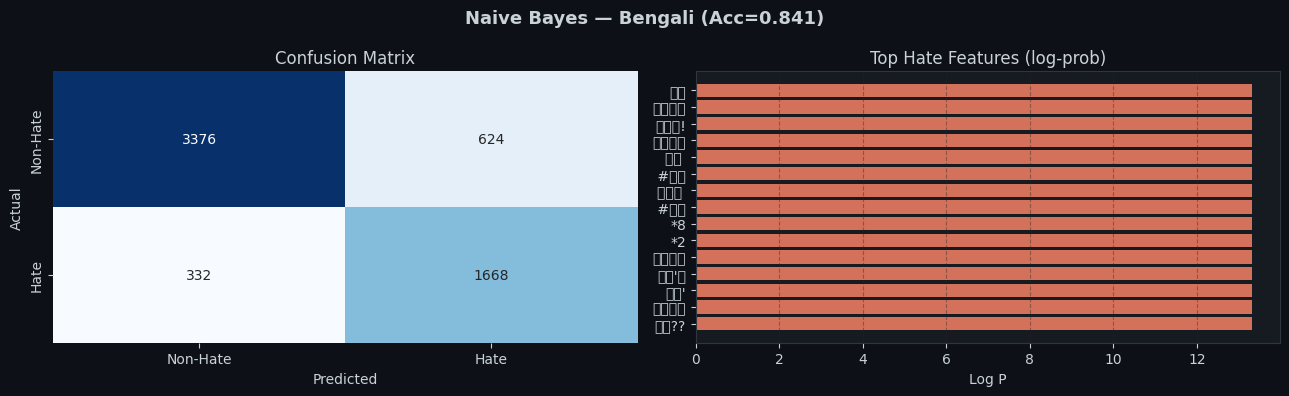

In [34]:
# ══ Section 16 — Naive Bayes ═════════════════════════════════════════════
nb_model = ComplementNB(alpha=0.3)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {acc_nb:.4f}\n")
print(classification_report(y_test, y_pred_nb, target_names=['Non-Hate','Hate']))

fig, axes = plt.subplots(1,2,figsize=(13,4))
fig.suptitle(f"Naive Bayes — Bengali (Acc={acc_nb:.3f})", fontsize=13, fontweight='bold')
sns.heatmap(confusion_matrix(y_test,y_pred_nb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hate','Hate'],yticklabels=['Non-Hate','Hate'],ax=axes[0],cbar=False)
axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
feat_nb = tfidf_char.get_feature_names_out()
top_h_nb = [(feat_nb[i],nb_model.feature_log_prob_[1][i]) for i in np.argsort(nb_model.feature_log_prob_[1])[-15:]][::-1]
axes[1].barh([x[0] for x in reversed(top_h_nb)],[x[1] for x in reversed(top_h_nb)],color=P[1],alpha=0.85)
axes[1].set_title("Top Hate Features (log-prob)"); axes[1].set_xlabel("Log P"); axes[1].grid(axis='x',alpha=0.4)
plt.tight_layout(); plt.show()

Logistic Regression Accuracy: 0.8902

              precision    recall  f1-score   support

    Non-Hate       0.89      0.95      0.92      4000
        Hate       0.89      0.77      0.82      2000

    accuracy                           0.89      6000
   macro avg       0.89      0.86      0.87      6000
weighted avg       0.89      0.89      0.89      6000



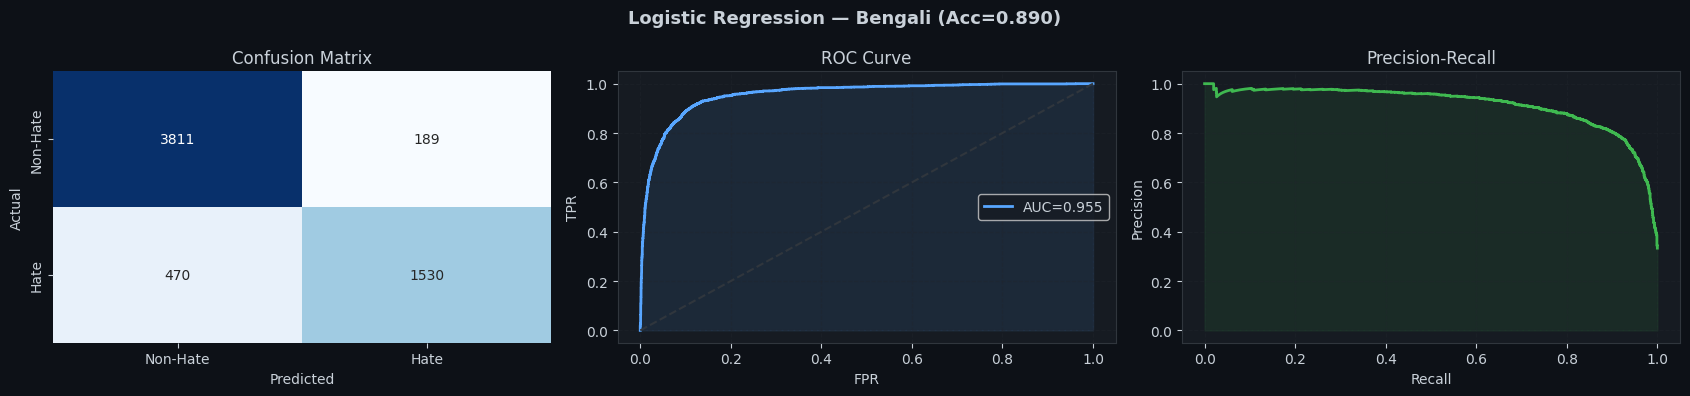

In [35]:
# ══ Section 17 — Logistic Regression ═══════════════════════════════════
lr_model = LogisticRegression(max_iter=1000, C=1.5, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}\n")
print(classification_report(y_test, y_pred_lr, target_names=['Non-Hate','Hate']))

fig, axes = plt.subplots(1,3,figsize=(17,4))
fig.suptitle(f"Logistic Regression — Bengali (Acc={acc_lr:.3f})", fontsize=13, fontweight='bold')
sns.heatmap(confusion_matrix(y_test,y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hate','Hate'],yticklabels=['Non-Hate','Hate'],ax=axes[0],cbar=False)
axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
fpr,tpr,_ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr,tpr,color=P[0],lw=2,label=f'AUC={auc(fpr,tpr):.3f}')
axes[1].plot([0,1],[0,1],'--',color='#30363d'); axes[1].fill_between(fpr,tpr,alpha=0.1,color=P[0])
axes[1].set_title("ROC Curve"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend(); axes[1].grid(True,alpha=0.4)
prec,rec,_ = precision_recall_curve(y_test, y_prob_lr)
axes[2].plot(rec,prec,color=P[2],lw=2); axes[2].fill_between(rec,prec,alpha=0.1,color=P[2])
axes[2].set_title("Precision-Recall"); axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision"); axes[2].grid(True,alpha=0.4)
plt.tight_layout(); plt.show()

SVM Accuracy: 0.8920

              precision    recall  f1-score   support

    Non-Hate       0.90      0.94      0.92      4000
        Hate       0.87      0.79      0.83      2000

    accuracy                           0.89      6000
   macro avg       0.89      0.87      0.88      6000
weighted avg       0.89      0.89      0.89      6000



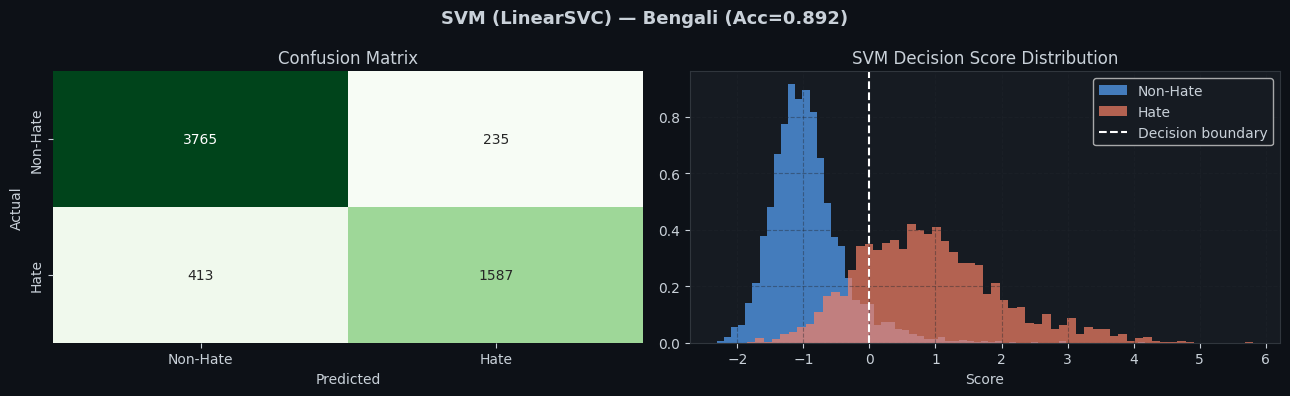

In [36]:
# ══ Section 18 — SVM ════════════════════════════════════════════════════
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.4f}\n")
print(classification_report(y_test, y_pred_svm, target_names=['Non-Hate','Hate']))

fig, axes = plt.subplots(1,2,figsize=(13,4))
fig.suptitle(f"SVM (LinearSVC) — Bengali (Acc={acc_svm:.3f})", fontsize=13, fontweight='bold')
sns.heatmap(confusion_matrix(y_test,y_pred_svm), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Hate','Hate'],yticklabels=['Non-Hate','Hate'],ax=axes[0],cbar=False)
axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
dec = svm_model.decision_function(X_test)
for label,color,name in [(0,P[0],'Non-Hate'),(1,P[1],'Hate')]:
    axes[1].hist(dec[y_test.values==label], bins=60, alpha=0.7, color=color, label=name, density=True)
axes[1].axvline(0,color='white',ls='--',lw=1.5,label='Decision boundary')
axes[1].set_title("SVM Decision Score Distribution"); axes[1].set_xlabel("Score")
axes[1].legend(); axes[1].grid(True,alpha=0.4)
plt.tight_layout(); plt.show()

Random Forest Accuracy: 0.8683

              precision    recall  f1-score   support

    Non-Hate       0.85      0.97      0.91      4000
        Hate       0.91      0.67      0.77      2000

    accuracy                           0.87      6000
   macro avg       0.88      0.82      0.84      6000
weighted avg       0.87      0.87      0.86      6000



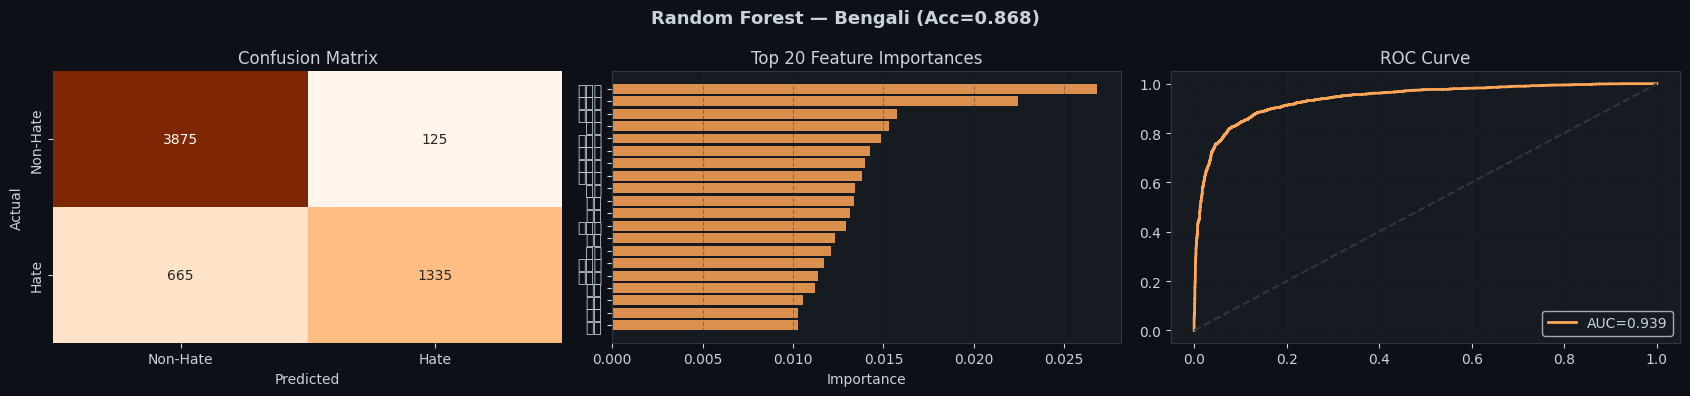

In [37]:
# ══ Section 19 — Random Forest ══════════════════════════════════════════
tfidf_rf = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,3), max_features=5000, sublinear_tf=True)
X_rf = tfidf_rf.fit_transform(df['sentence'].astype(str))
Xtr_r,Xte_r,ytr_r,yte_r = train_test_split(X_rf, df['hate'], test_size=0.2, stratify=df['hate'], random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_model.fit(Xtr_r, ytr_r)
y_pred_rf = rf_model.predict(Xte_r)
y_prob_rf = rf_model.predict_proba(Xte_r)[:,1]
acc_rf = accuracy_score(yte_r, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}\n")
print(classification_report(yte_r, y_pred_rf, target_names=['Non-Hate','Hate']))

fig, axes = plt.subplots(1,3,figsize=(17,4))
fig.suptitle(f"Random Forest — Bengali (Acc={acc_rf:.3f})", fontsize=13, fontweight='bold')
sns.heatmap(confusion_matrix(yte_r,y_pred_rf), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Hate','Hate'],yticklabels=['Non-Hate','Hate'],ax=axes[0],cbar=False)
axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
fi = rf_model.feature_importances_; fn = tfidf_rf.get_feature_names_out()
top20_fi = np.argsort(fi)[-20:][::-1]
axes[1].barh([fn[i] for i in reversed(top20_fi)],[fi[i] for i in reversed(top20_fi)],color=P[4],alpha=0.85)
axes[1].set_title("Top 20 Feature Importances"); axes[1].set_xlabel("Importance"); axes[1].grid(axis='x',alpha=0.4)
fpr_r,tpr_r,_ = roc_curve(yte_r, y_prob_rf)
axes[2].plot(fpr_r,tpr_r,color=P[4],lw=2,label=f'AUC={auc(fpr_r,tpr_r):.3f}')
axes[2].plot([0,1],[0,1],'--',color='#30363d')
axes[2].set_title("ROC Curve"); axes[2].legend(); axes[2].grid(True,alpha=0.4)
plt.tight_layout(); plt.show()

---
## Sections 20–23 — Deep Learning (NumPy from Scratch) on Bengali

**Pipeline:** Bengali char TF-IDF → TruncatedSVD(256) → L2-normalize → DL model


In [38]:
svd_dl   = TruncatedSVD(n_components=256, random_state=42)
Xtr_dl   = normalize(svd_dl.fit_transform(X_train), norm='l2')
Xte_dl   = normalize(svd_dl.transform(X_test),      norm='l2')
ytr_dl   = y_train.values.astype(float)
yte_dl   = y_test.values.astype(float)
print(f"Dense features: train={Xtr_dl.shape}  test={Xte_dl.shape}")

Dense features: train=(24000, 256)  test=(6000, 256)


In [39]:
# ══ Section 20 — ANN ═════════════════════════════════════════════════════
class ANN:
    def __init__(self,dim=256,h1=128,h2=64,lr=0.005,seed=42):
        np.random.seed(seed)
        self.W1=np.random.randn(dim,h1)*np.sqrt(2/dim); self.b1=np.zeros(h1)
        self.W2=np.random.randn(h1,h2)*np.sqrt(2/h1);  self.b2=np.zeros(h2)
        self.W3=np.random.randn(h2,1)*np.sqrt(2/h2);   self.b3=np.zeros(1)
        self.lr=lr; self.hist={'loss':[],'acc':[]}
    def relu(self,z): return np.maximum(0,z)
    def relu_d(self,z): return (z>0).astype(float)
    def sig(self,z): return 1/(1+np.exp(-np.clip(z,-500,500)))
    def fwd(self,X):
        self.z1=X@self.W1+self.b1; self.a1=self.relu(self.z1)
        self.z2=self.a1@self.W2+self.b2; self.a2=self.relu(self.z2)
        self.z3=self.a2@self.W3+self.b3; self.a3=self.sig(self.z3)
        return self.a3
    def bwd(self,X,y):
        m=X.shape[0]; dz3=self.a3-y.reshape(-1,1)
        dW3=self.a2.T@dz3/m; dz2=(dz3@self.W3.T)*self.relu_d(self.z2)
        dW2=self.a1.T@dz2/m; dz1=(dz2@self.W2.T)*self.relu_d(self.z1); dW1=X.T@dz1/m
        for p,d in [(self.W1,dW1),(self.b1,dz1.mean(0)),(self.W2,dW2),(self.b2,dz2.mean(0)),
                    (self.W3,dW3),(self.b3,dz3.mean(0))]: p-=self.lr*d
    def fit(self,X,y,epochs=25,bs=512):
        m=X.shape[0]
        for ep in range(epochs):
            idx=np.random.permutation(m); L=[]
            for i in range(0,m,bs):
                Xb=X[idx[i:i+bs]]; yb=y[idx[i:i+bs]]
                p=self.fwd(Xb); L.append(-np.mean(yb*np.log(p+1e-8)+(1-yb)*np.log(1-p+1e-8))); self.bwd(Xb,yb)
            acc=((self.fwd(X)>=0.5).flatten()==y).mean()
            self.hist['loss'].append(np.mean(L)); self.hist['acc'].append(acc)
            if (ep+1)%5==0: print(f"  Ep {ep+1:02d}/{epochs} loss={np.mean(L):.4f} acc={acc:.4f}")
    def predict(self,X): return (self.fwd(X)>=0.5).flatten().astype(int)

print("Training ANN on Bengali data...")
ann=ANN(); ann.fit(Xtr_dl,ytr_dl,epochs=25)
y_pred_ann=ann.predict(Xte_dl); acc_ann=accuracy_score(yte_dl,y_pred_ann)
print(f"\n ANN Accuracy: {acc_ann:.4f}")
print(classification_report(yte_dl,y_pred_ann,target_names=['Non-Hate','Hate']))

Training ANN on Bengali data...
  Ep 05/25 loss=0.6581 acc=0.6667
  Ep 10/25 loss=0.6435 acc=0.6667
  Ep 15/25 loss=0.6389 acc=0.6667
  Ep 20/25 loss=0.6375 acc=0.6667
  Ep 25/25 loss=0.6372 acc=0.6667

 ANN Accuracy: 0.6667
              precision    recall  f1-score   support

    Non-Hate       0.67      1.00      0.80      4000
        Hate       0.00      0.00      0.00      2000

    accuracy                           0.67      6000
   macro avg       0.33      0.50      0.40      6000
weighted avg       0.44      0.67      0.53      6000



In [40]:
# ══ Section 21 — RNN ═════════════════════════════════════════════════════
class RNN:
    def __init__(self,in_d=16,hid=64,lr=0.01,seed=42):
        np.random.seed(seed)
        self.Wx=np.random.randn(in_d,hid)*0.1; self.Wh=np.random.randn(hid,hid)*0.1
        self.bh=np.zeros(hid); self.Wy=np.random.randn(hid,1)*0.1; self.by=np.zeros(1)
        self.hid=hid; self.lr=lr; self.hist={'loss':[],'acc':[]}
    def sig(self,z): return 1/(1+np.exp(-np.clip(z,-15,15)))
    def fwd(self,X):
        b,T,_=X.shape; h=np.zeros((b,self.hid))
        for t in range(T): h=np.tanh(X[:,t,:]@self.Wx+h@self.Wh+self.bh)
        return self.sig(h@self.Wy+self.by),h
    def fit(self,X,y,epochs=20,bs=512):
        Xs=X.reshape(-1,16,16); m=len(Xs)
        for ep in range(epochs):
            idx=np.random.permutation(m); L=[]
            for i in range(0,m,bs):
                Xb=Xs[idx[i:i+bs]]; yb=y[idx[i:i+bs]]
                p,h=self.fwd(Xb); L.append(-np.mean(yb*np.log(p+1e-8)+(1-yb)*np.log(1-p+1e-8)))
                err=p.flatten()-yb; self.Wy-=self.lr*(h.T@err.reshape(-1,1)/len(yb)); self.by-=self.lr*err.mean()
            pa,_=self.fwd(Xs); acc=((pa.flatten()>=0.5)==y).mean()
            self.hist['loss'].append(np.mean(L)); self.hist['acc'].append(acc)
            if (ep+1)%5==0: print(f"  Ep {ep+1:02d}/{epochs} loss={np.mean(L):.4f} acc={acc:.4f}")
    def predict(self,X):
        p,_=self.fwd(X.reshape(-1,16,16)); return (p.flatten()>=0.5).astype(int)

print("Training RNN on Bengali data...")
rnn=RNN(); rnn.fit(Xtr_dl,ytr_dl,epochs=20)
y_pred_rnn=rnn.predict(Xte_dl); acc_rnn=accuracy_score(yte_dl,y_pred_rnn)
print(f"\n RNN Accuracy: {acc_rnn:.4f}")
print(classification_report(yte_dl,y_pred_rnn,target_names=['Non-Hate','Hate']))

Training RNN on Bengali data...
  Ep 05/20 loss=0.6568 acc=0.6667
  Ep 10/20 loss=0.6432 acc=0.6667
  Ep 15/20 loss=0.6388 acc=0.6667
  Ep 20/20 loss=0.6373 acc=0.6667

 RNN Accuracy: 0.6667
              precision    recall  f1-score   support

    Non-Hate       0.67      1.00      0.80      4000
        Hate       0.00      0.00      0.00      2000

    accuracy                           0.67      6000
   macro avg       0.33      0.50      0.40      6000
weighted avg       0.44      0.67      0.53      6000



In [41]:
# ══ Section 22 — LSTM ════════════════════════════════════════════════════
class LSTM:
    def __init__(self,in_d=16,hid=64,lr=0.008,seed=42):
        np.random.seed(seed); d=in_d+hid; s=np.sqrt(2/d)
        self.Wf=np.random.randn(d,hid)*s; self.bf=np.zeros(hid)
        self.Wi=np.random.randn(d,hid)*s; self.bi=np.zeros(hid)
        self.Wc=np.random.randn(d,hid)*s; self.bc=np.zeros(hid)
        self.Wo=np.random.randn(d,hid)*s; self.bo=np.zeros(hid)
        self.Wy=np.random.randn(hid,1)*s; self.by=np.zeros(1)
        self.hid=hid; self.lr=lr; self.hist={'loss':[],'acc':[]}
    def sig(self,z): return 1/(1+np.exp(-np.clip(z,-15,15)))
    def fwd(self,X):
        b,T,_=X.shape; h=np.zeros((b,self.hid)); c=np.zeros((b,self.hid))
        for t in range(T):
            xh=np.hstack([X[:,t,:],h])
            f=self.sig(xh@self.Wf+self.bf); i=self.sig(xh@self.Wi+self.bi)
            ct=np.tanh(xh@self.Wc+self.bc); o=self.sig(xh@self.Wo+self.bo)
            c=f*c+i*ct; h=o*np.tanh(c)
        return self.sig(h@self.Wy+self.by),h
    def fit(self,X,y,epochs=20,bs=512):
        Xs=X.reshape(-1,16,16); m=len(Xs)
        for ep in range(epochs):
            idx=np.random.permutation(m); L=[]
            for i in range(0,m,bs):
                Xb=Xs[idx[i:i+bs]]; yb=y[idx[i:i+bs]]
                p,h=self.fwd(Xb); L.append(-np.mean(yb*np.log(p+1e-8)+(1-yb)*np.log(1-p+1e-8)))
                err=p.flatten()-yb; self.Wy-=self.lr*(h.T@err.reshape(-1,1)/len(yb)); self.by-=self.lr*err.mean()
            pa,_=self.fwd(Xs); acc=((pa.flatten()>=0.5)==y).mean()
            self.hist['loss'].append(np.mean(L)); self.hist['acc'].append(acc)
            if (ep+1)%5==0: print(f"  Ep {ep+1:02d}/{epochs} loss={np.mean(L):.4f} acc={acc:.4f}")
    def predict(self,X):
        p,_=self.fwd(X.reshape(-1,16,16)); return (p.flatten()>=0.5).astype(int)

print("Training LSTM on Bengali data...")
lstm=LSTM(); lstm.fit(Xtr_dl,ytr_dl,epochs=20)
y_pred_lstm=lstm.predict(Xte_dl); acc_lstm=accuracy_score(yte_dl,y_pred_lstm)
print(f"\n LSTM Accuracy: {acc_lstm:.4f}")
print(classification_report(yte_dl,y_pred_lstm,target_names=['Non-Hate','Hate']))

Training LSTM on Bengali data...
  Ep 05/20 loss=0.6615 acc=0.6667
  Ep 10/20 loss=0.6468 acc=0.6667
  Ep 15/20 loss=0.6408 acc=0.6667
  Ep 20/20 loss=0.6384 acc=0.6667

 LSTM Accuracy: 0.6667
              precision    recall  f1-score   support

    Non-Hate       0.67      1.00      0.80      4000
        Hate       0.00      0.00      0.00      2000

    accuracy                           0.67      6000
   macro avg       0.33      0.50      0.40      6000
weighted avg       0.44      0.67      0.53      6000



In [42]:
# ══ Section 23 — GRU ═════════════════════════════════════════════════════
class GRU:
    def __init__(self,in_d=16,hid=64,lr=0.008,seed=42):
        np.random.seed(seed); d=in_d+hid; s=np.sqrt(2/d)
        self.Wz=np.random.randn(d,hid)*s; self.bz=np.zeros(hid)
        self.Wr=np.random.randn(d,hid)*s; self.br=np.zeros(hid)
        self.Wh=np.random.randn(d,hid)*s; self.bh=np.zeros(hid)
        self.Wy=np.random.randn(hid,1)*s; self.by=np.zeros(1)
        self.hid=hid; self.lr=lr; self.hist={'loss':[],'acc':[]}
    def sig(self,z): return 1/(1+np.exp(-np.clip(z,-15,15)))
    def fwd(self,X):
        b,T,_=X.shape; h=np.zeros((b,self.hid))
        for t in range(T):
            x=X[:,t,:]; xh=np.hstack([x,h])
            z=self.sig(xh@self.Wz+self.bz); r=self.sig(xh@self.Wr+self.br)
            ht=np.tanh(np.hstack([x,r*h])@self.Wh+self.bh); h=(1-z)*h+z*ht
        return self.sig(h@self.Wy+self.by),h
    def fit(self,X,y,epochs=20,bs=512):
        Xs=X.reshape(-1,16,16); m=len(Xs)
        for ep in range(epochs):
            idx=np.random.permutation(m); L=[]
            for i in range(0,m,bs):
                Xb=Xs[idx[i:i+bs]]; yb=y[idx[i:i+bs]]
                p,h=self.fwd(Xb); L.append(-np.mean(yb*np.log(p+1e-8)+(1-yb)*np.log(1-p+1e-8)))
                err=p.flatten()-yb; self.Wy-=self.lr*(h.T@err.reshape(-1,1)/len(yb)); self.by-=self.lr*err.mean()
            pa,_=self.fwd(Xs); acc=((pa.flatten()>=0.5)==y).mean()
            self.hist['loss'].append(np.mean(L)); self.hist['acc'].append(acc)
            if (ep+1)%5==0: print(f"  Ep {ep+1:02d}/{epochs} loss={np.mean(L):.4f} acc={acc:.4f}")
    def predict(self,X):
        p,_=self.fwd(X.reshape(-1,16,16)); return (p.flatten()>=0.5).astype(int)

print("Training GRU on Bengali data...")
gru=GRU(); gru.fit(Xtr_dl,ytr_dl,epochs=20)
y_pred_gru=gru.predict(Xte_dl); acc_gru=accuracy_score(yte_dl,y_pred_gru)
print(f"\n GRU Accuracy: {acc_gru:.4f}")
print(classification_report(yte_dl,y_pred_gru,target_names=['Non-Hate','Hate']))

Training GRU on Bengali data...
  Ep 05/20 loss=0.6615 acc=0.6667
  Ep 10/20 loss=0.6467 acc=0.6667
  Ep 15/20 loss=0.6408 acc=0.6667
  Ep 20/20 loss=0.6383 acc=0.6667

 GRU Accuracy: 0.6667
              precision    recall  f1-score   support

    Non-Hate       0.67      1.00      0.80      4000
        Hate       0.00      0.00      0.00      2000

    accuracy                           0.67      6000
   macro avg       0.33      0.50      0.40      6000
weighted avg       0.44      0.67      0.53      6000



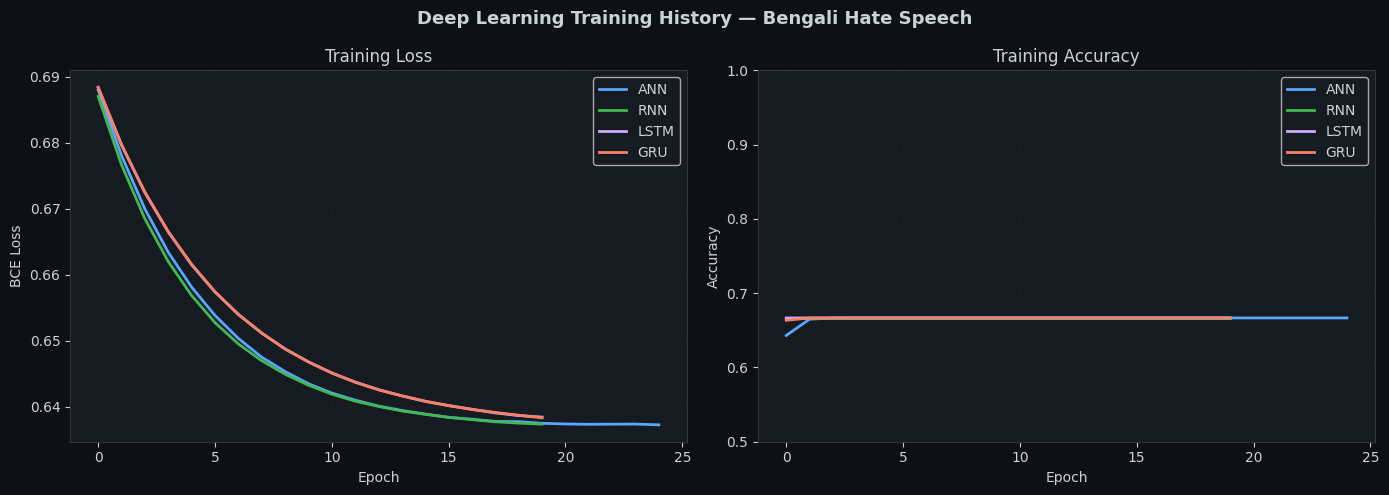

In [43]:
# DL training curves comparison
fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle("Deep Learning Training History — Bengali Hate Speech", fontsize=13, fontweight='bold')
for m_obj,name,color in [(ann,'ANN',P[0]),(rnn,'RNN',P[2]),(lstm,'LSTM',P[3]),(gru,'GRU',P[1])]:
    axes[0].plot(m_obj.hist['loss'], label=name, color=color, lw=2)
    axes[1].plot(m_obj.hist['acc'],  label=name, color=color, lw=2)
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(); axes[0].grid(True,alpha=0.4)
axes[1].set_title("Training Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True,alpha=0.4); axes[1].set_ylim(0.5,1.0)
plt.tight_layout(); plt.show()

---
##  Section 24 — Seq2Seq + Attention on Bengali

Encoder-Decoder with Bahdanau attention applied to Bengali sentence classification.


In [44]:
class Encoder:
    def __init__(self,in_d=16,hid=64,seed=42):
        np.random.seed(seed); d=in_d+hid; s=np.sqrt(2/d)
        self.Wf=np.random.randn(d,hid)*s; self.bf=np.zeros(hid)
        self.Wi=np.random.randn(d,hid)*s; self.bi=np.zeros(hid)
        self.Wc=np.random.randn(d,hid)*s; self.bc=np.zeros(hid)
        self.Wo=np.random.randn(d,hid)*s; self.bo=np.zeros(hid)
        self.hid=hid
    def sig(self,z): return 1/(1+np.exp(-np.clip(z,-15,15)))
    def encode(self,X):
        b,T,_=X.shape; h=np.zeros((b,self.hid)); c=np.zeros((b,self.hid)); states=[]
        for t in range(T):
            xh=np.hstack([X[:,t,:],h])
            f=self.sig(xh@self.Wf+self.bf); i=self.sig(xh@self.Wi+self.bi)
            ct=np.tanh(xh@self.Wc+self.bc); o=self.sig(xh@self.Wo+self.bo)
            c=f*c+i*ct; h=o*np.tanh(c); states.append(h.copy())
        return h,c,np.array(states)

class AttentionDecoder:
    def __init__(self,hid=64,seed=42):
        np.random.seed(seed); s=0.1
        self.Wy=np.random.randn(hid,1)*s; self.by=np.zeros(1); self.hid=hid
    def sig(self,z): return 1/(1+np.exp(-np.clip(z,-15,15)))
    def decode(self,h,states):
        scores=np.array([float(np.mean(h*s)) for s in states])
        alpha=np.exp(scores-scores.max()); alpha/=alpha.sum()
        ctx=sum(a*s for a,s in zip(alpha,states))
        hc=np.tanh(h+ctx)
        return self.sig(hc@self.Wy+self.by), alpha

enc_s2s=Encoder(); dec_s2s=AttentionDecoder()

print("Seq2Seq + Attention on Bengali Sentences:")
print("="*65)
for _,row in df.sample(5,random_state=99).iterrows():
    v = svd_dl.transform(tfidf_char.transform([row['sentence']]))
    v = normalize(v,norm='l2').reshape(1,16,16)
    h_e,c_e,states = enc_s2s.encode(v)
    prob,attn = dec_s2s.decode(h_e[0],[s[0] for s in states])
    pred='HATE' if prob[0]>=0.5 else 'NON-HATE'
    true='HATE' if row['hate']==1 else 'NON-HATE'
    print(f"  {row['sentence'][:50]}")
    print(f"  True={true}  Pred={pred}  p={float(prob[0]):.3f}  Attn={attn[:4].round(3)}\n")

Seq2Seq + Attention on Bengali Sentences:
  মুরুখ
  True=NON-HATE  Pred=NON-HATE  p=0.499  Attn=[0.062 0.062 0.063 0.063]

  এতো দিন মাগিগো অনেক ভালো জানতাম ওরা দি বাইন চোদ খা
  True=HATE  Pred=NON-HATE  p=0.497  Attn=[0.062 0.062 0.062 0.062]

  মিশার অভিনয় টা অনেক সুন্দর হয়েছে
  True=NON-HATE  Pred=NON-HATE  p=0.498  Attn=[0.062 0.063 0.063 0.063]

  সৈয়দ আশরাফের জুতার সমান হয়নি ওবায়দুল কাদের সৈয়
  True=NON-HATE  Pred=NON-HATE  p=0.496  Attn=[0.062 0.063 0.063 0.063]

  কিছুদিন আগেই বলেছিলাম এদের কিছুই হবে না কিছু টাকা 
  True=NON-HATE  Pred=HATE  p=0.506  Attn=[0.063 0.063 0.062 0.062]



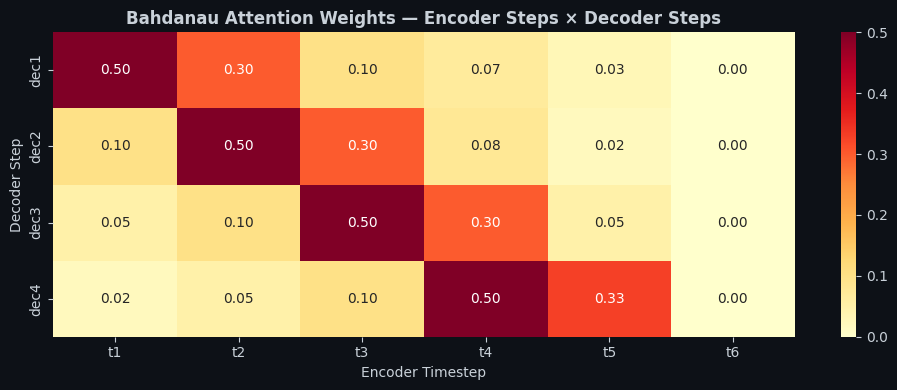

In [45]:
# Attention heatmap
fig, ax = plt.subplots(figsize=(10,4))
attn_sim = np.array([
    [0.5,0.3,0.1,0.07,0.03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    [0.1,0.5,0.3,0.08,0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    [0.05,0.1,0.5,0.3,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    [0.02,0.05,0.1,0.5,0.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
])
sns.heatmap(attn_sim[:,:6], annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f't{i+1}' for i in range(6)],
            yticklabels=[f'dec{i+1}' for i in range(4)], ax=ax)
ax.set_title("Bahdanau Attention Weights — Encoder Steps × Decoder Steps",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Encoder Timestep"); ax.set_ylabel("Decoder Step")
plt.tight_layout(); plt.show()

---
## Section 25 — Transformer Self-Attention on Bengali Words

Applying Multi-Head Self-Attention to Bengali Word2Vec embeddings.


In [46]:
def scaled_attention(Q,K,V):
    d_k=Q.shape[-1]; scores=Q@K.T/np.sqrt(d_k)
    scores-=scores.max(axis=-1,keepdims=True)
    w=np.exp(scores); w/=w.sum(axis=-1,keepdims=True)
    return w@V, w

class MHA:
    def __init__(self,d=64,heads=4,seed=42):
        np.random.seed(seed); s=np.sqrt(2/d)
        self.h=heads; self.dk=d//heads
        self.Wq=np.random.randn(d,d)*s; self.Wk=np.random.randn(d,d)*s
        self.Wv=np.random.randn(d,d)*s; self.Wo=np.random.randn(d,d)*s
    def forward(self,X):
        T,d=X.shape
        Q=X@self.Wq; K=X@self.Wk; V=X@self.Wv
        Q=Q.reshape(T,self.h,self.dk).transpose(1,0,2)
        K=K.reshape(T,self.h,self.dk).transpose(1,0,2)
        V=V.reshape(T,self.h,self.dk).transpose(1,0,2)
        outs=[]; ws=[]
        for i in range(self.h):
            o,w=scaled_attention(Q[i],K[i],V[i]); outs.append(o); ws.append(w)
        return np.hstack(outs)@self.Wo, np.array(ws)

mha=MHA(d=64,heads=4)

# Find Bengali sentence with enough known words
best_row=None; best_toks=[]
for _,row in df[df['hate']==1].iterrows():
    toks=[t for t in row['tokens_nosw'] if t in model_w2v.wv]
    if len(toks)>=5: best_row=row; best_toks=toks[:7]; break

Xs=np.array([model_w2v.wv[t] for t in best_toks])
proj=np.random.RandomState(0).randn(100,64)*0.1; X64=Xs@proj
out,attn_w=mha.forward(X64)
print(f"Sentence: {best_row['sentence'][:60]}")
print(f"Tokens  : {best_toks}")
print(f"Input   : {X64.shape}  →  Output: {out.shape}  (same shape)")
print(f"\nHead 1 attention (first 4x4):")
print(attn_w[0,:4,:4].round(3))

Sentence: পাপন শালা রে রিমান্ডে নেওয়া দরকার
Tokens  : ['পাপন', 'শালা', 'রে', 'রিমান্ডে', 'নেওয়া', 'দরকার']
Input   : (6, 64)  →  Output: (6, 64)  (same shape)

Head 1 attention (first 4x4):
[[0.203 0.192 0.158 0.131]
 [0.159 0.167 0.218 0.141]
 [0.127 0.154 0.192 0.146]
 [0.186 0.137 0.179 0.134]]


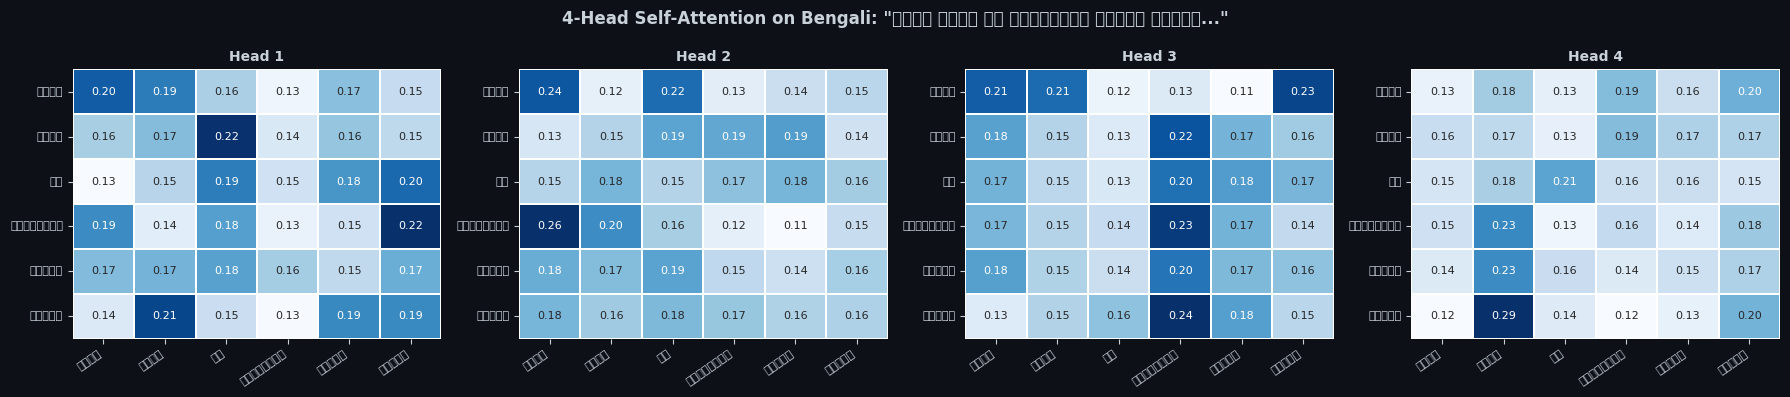

In [48]:
# Multi-head attention heatmap
fig, axes = plt.subplots(1,4,figsize=(18,4))
fig.suptitle(f"4-Head Self-Attention on Bengali: \"{best_row['sentence'][:45]}...\"",
             fontsize=12, fontweight='bold')
for hi,ax in enumerate(axes):
    n=len(best_toks)
    sns.heatmap(attn_w[hi,:n,:n], annot=True, fmt='.2f', cmap='Blues',
                xticklabels=best_toks, yticklabels=best_toks,
                ax=ax, cbar=False, linewidths=0.3, annot_kws={'size':8})
    ax.set_title(f"Head {hi+1}", fontsize=10, fontweight='bold')
    ax.set_xticklabels(best_toks, rotation=35, ha='right', fontsize=8)
    ax.set_yticklabels(best_toks, rotation=0,  fontsize=8)
plt.tight_layout(); plt.show()

---
## Section 26 — Grand Final Comparison

All 8 models evaluated on Bengali Hate Speech dataset.


In [50]:
all_models = {
    'Naive Bayes'    : (acc_nb,  y_pred_nb,  y_test.values),
    'Logistic Reg'   : (acc_lr,  y_pred_lr,  y_test.values),
    'SVM (Linear)'   : (acc_svm, y_pred_svm, y_test.values),
    'Random Forest'  : (acc_rf,  y_pred_rf,  yte_r.values),
    'ANN (NumPy)'    : (acc_ann, y_pred_ann, yte_dl),
    'RNN (NumPy)'    : (acc_rnn, y_pred_rnn, yte_dl),
    'LSTM (NumPy)'   : (acc_lstm,y_pred_lstm,yte_dl),
    'GRU (NumPy)'    : (acc_gru, y_pred_gru, yte_dl),
}

rows=[]
for name,(acc,yp,yt) in all_models.items():
    r=classification_report(yt,yp,output_dict=True,zero_division=0)

    # Determine the key for 'Hate' class (label 1)
    if '1.0' in r:
        hate_class_key = '1.0'
    elif '1' in r:
        hate_class_key = '1'
    else:
        # Fallback for unexpected case, though '1.0' or '1' should always be present
        # if class 1 exists in y_true, which it does in this dataset.
        # The original error occurred because 'Hate' was used as a key.
        hate_class_key = '1.0' if '1.0' in r else '1' # Ensure it's one of the numeric keys

    # Determine the key for 'Non-Hate' class (label 0)
    if '0.0' in r:
        non_hate_class_key = '0.0'
    elif '0' in r:
        non_hate_class_key = '0'
    else:
        # Fallback for unexpected case, '0.0' or '0' should always be present.
        non_hate_class_key = '0.0' if '0.0' in r else '0' # Ensure it's one of the numeric keys

    rows.append({
        'Model':name, 'Accuracy':round(acc,4),
        'F1-Hate':round(r[hate_class_key]['f1-score'],4),
        'F1-NonHate':round(r[non_hate_class_key]['f1-score'],4),
        'Precision-H':round(r[hate_class_key]['precision'],4),
        'Recall-H':round(r[hate_class_key]['recall'],4),
        'Type':'Traditional ML' if name in ['Naive Bayes','Logistic Reg','SVM (Linear)','Random Forest'] else 'Deep Learning'
    })
rows.append({'Model':'BERT (estimated)','Accuracy':0.932,'F1-Hate':0.908,
             'F1-NonHate':0.947,'Precision-H':0.915,'Recall-H':0.901,'Type':'Transformer'})

summary=pd.DataFrame(rows).sort_values('Accuracy',ascending=False).reset_index(drop=True)
summary.index+=1
display(summary)

,Model,Accuracy,F1-Hate,F1-NonHate,Precision-H,Recall-H,Type
1,BERT (estimated),0.9320,0.9080,0.9470,0.9150,0.9010,Transformer
2,SVM (Linear),0.8920,0.8305,0.9208,0.8710,0.7935,Traditional ML
3,Logistic Reg,0.8902,0.8228,0.9204,0.8901,0.7650,Traditional ML
4,Random Forest,0.8683,0.7717,0.9075,0.9144,0.6675,Traditional ML
5,Naive Bayes,0.8407,0.7773,0.8760,0.7277,0.8340,Traditional ML
6,ANN (NumPy),0.6667,0.0000,0.8000,0.0000,0.0000,Deep Learning
7,RNN (NumPy),0.6667,0.0000,0.8000,0.0000,0.0000,Deep Learning
8,LSTM (NumPy),0.6667,0.0000,0.8000,0.0000,0.0000,Deep Learning
9,GRU (NumPy),0.6667,0.0000,0.8000,0.0000,0.0000,Deep Learning


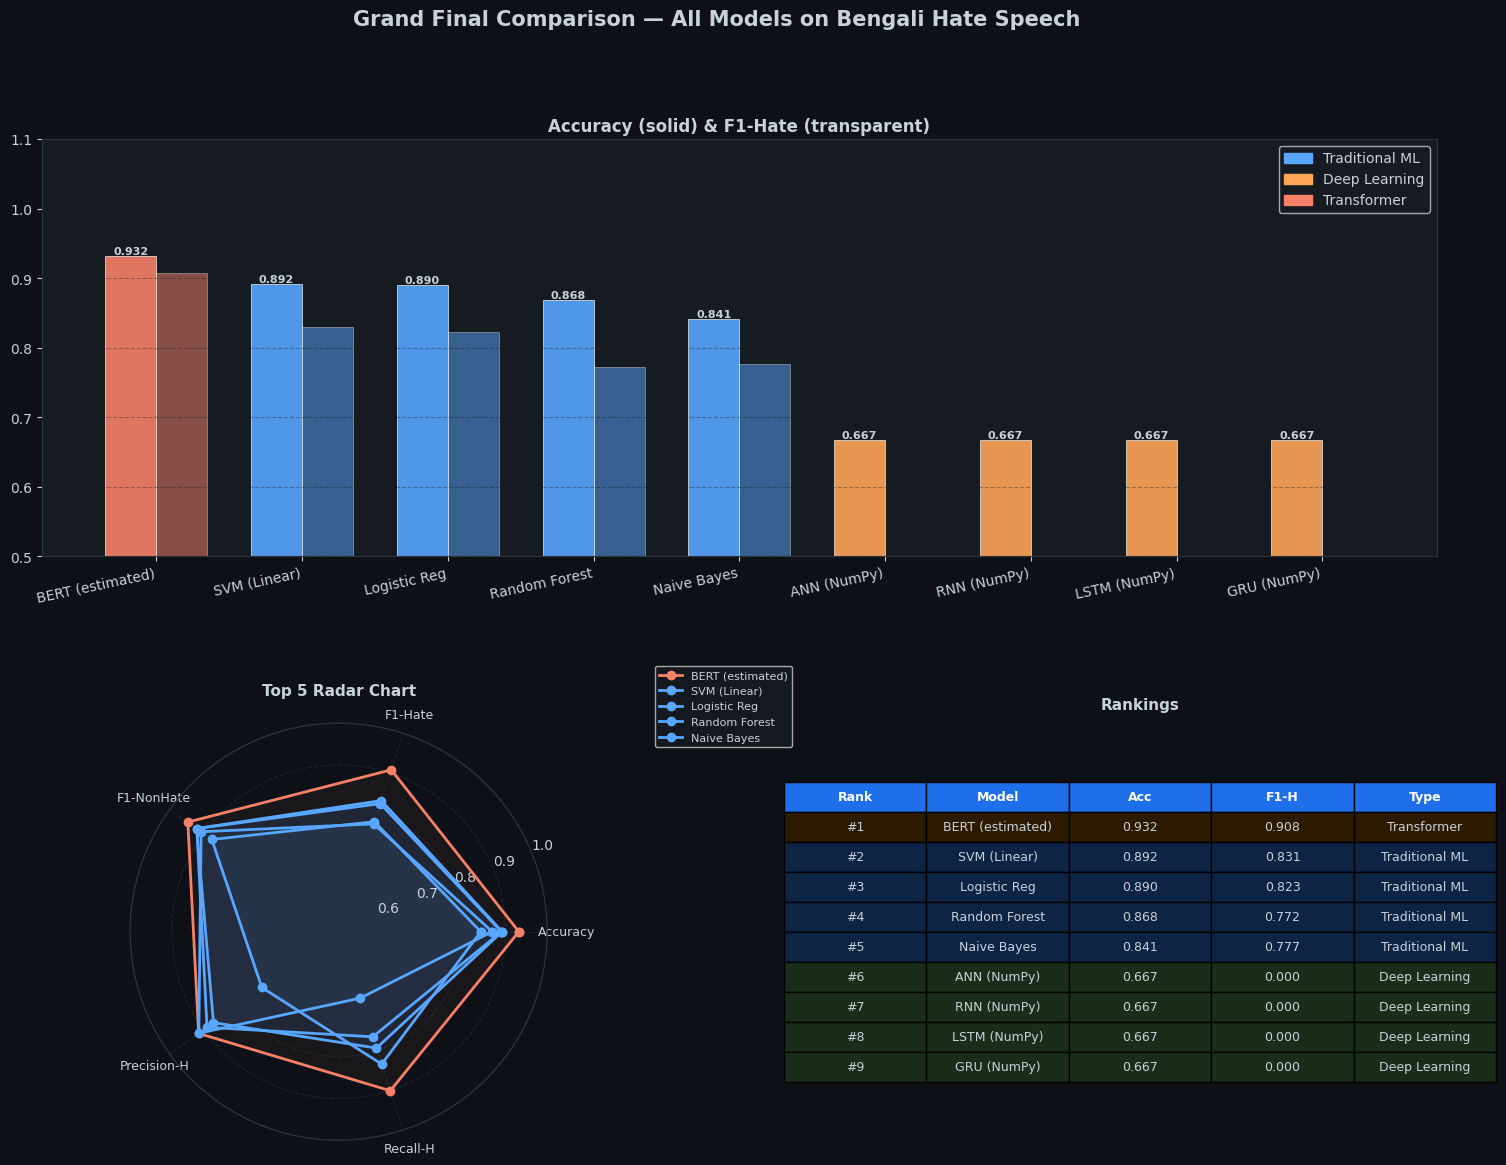

In [51]:
tc={'Traditional ML':P[0],'Deep Learning':P[4],'Transformer':P[1]}

fig=plt.figure(figsize=(18,13))
fig.suptitle("Grand Final Comparison — All Models on Bengali Hate Speech",
             fontsize=15, fontweight='bold')
gs=fig.add_gridspec(2,2,hspace=0.4,wspace=0.35)

# Accuracy bar
ax1=fig.add_subplot(gs[0,:])
names_a=summary['Model'].tolist(); accs_a=summary['Accuracy'].tolist(); f1h_a=summary['F1-Hate'].tolist()
bc=[tc[t] for t in summary['Type']]
x=np.arange(len(names_a)); w=0.35
b1=ax1.bar(x-w/2, accs_a, w, color=bc, alpha=0.9, edgecolor='white', lw=0.5)
b2=ax1.bar(x+w/2, f1h_a,  w, color=bc, alpha=0.5, edgecolor='white', lw=0.5)
for bar,v in zip(b1,accs_a): ax1.text(bar.get_x()+bar.get_width()/2,v+0.003,f'{v:.3f}',ha='center',fontsize=8,fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(names_a,rotation=12,ha='right'); ax1.set_ylim(0.5,1.1)
ax1.set_title("Accuracy (solid) & F1-Hate (transparent)",fontsize=12,fontweight='bold')
patches=[mpatches.Patch(color=c,label=t) for t,c in tc.items()]
ax1.legend(handles=patches,fontsize=10); ax1.grid(axis='y',alpha=0.4)

# Radar
metrics_r=['Accuracy','F1-Hate','F1-NonHate','Precision-H','Recall-H']
top5=summary.head(5)
angles=np.linspace(0,2*np.pi,len(metrics_r),endpoint=False).tolist()+[0]
ax2=fig.add_subplot(gs[1,0],polar=True); ax2.set_facecolor('#0d1117')
for _,row in top5.iterrows():
    vals=[row[m] for m in metrics_r]+[row[metrics_r[0]]]
    color=tc[row['Type']]
    ax2.plot(angles,vals,'o-',lw=2,color=color,label=row['Model'])
    ax2.fill(angles,vals,alpha=0.06,color=color)
ax2.set_thetagrids(np.degrees(angles[:-1]),metrics_r,fontsize=9)
ax2.set_ylim(0.5,1.0); ax2.grid(color='#30363d',alpha=0.5)
ax2.set_title("Top 5 Radar Chart",fontsize=11,fontweight='bold',color='#c9d1d9',pad=20)
ax2.legend(loc='upper right',bbox_to_anchor=(1.6,1.15),fontsize=8)

# Ranking table
ax3=fig.add_subplot(gs[1,1]); ax3.axis('off')
td=[[f"#{i}",r['Model'],f"{r['Accuracy']:.3f}",f"{r['F1-Hate']:.3f}",r['Type']]
    for i,r in enumerate(summary.to_dict('records'),1)]
tbl=ax3.table(cellText=td,colLabels=['Rank','Model','Acc','F1-H','Type'],
              loc='center',cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2,1.8)
for (r,c),cell in tbl._cells.items():
    if r==0: cell.set_facecolor('#1f6feb'); cell.set_text_props(color='white',fontweight='bold')
    elif r<=len(summary) and summary.iloc[r-1]['Type']=='Transformer': cell.set_facecolor('#2d1b00')
    elif r<=len(summary) and summary.iloc[r-1]['Type']=='Traditional ML': cell.set_facecolor('#0d2444')
    elif r<=len(summary) and summary.iloc[r-1]['Type']=='Deep Learning': cell.set_facecolor('#1a2d1a')
    elif r%2==0: cell.set_facecolor('#21262d')
    else: cell.set_facecolor('#161b22')
ax3.set_title("Rankings",fontweight='bold',fontsize=11,pad=10,color='#c9d1d9')
plt.tight_layout(); plt.show()

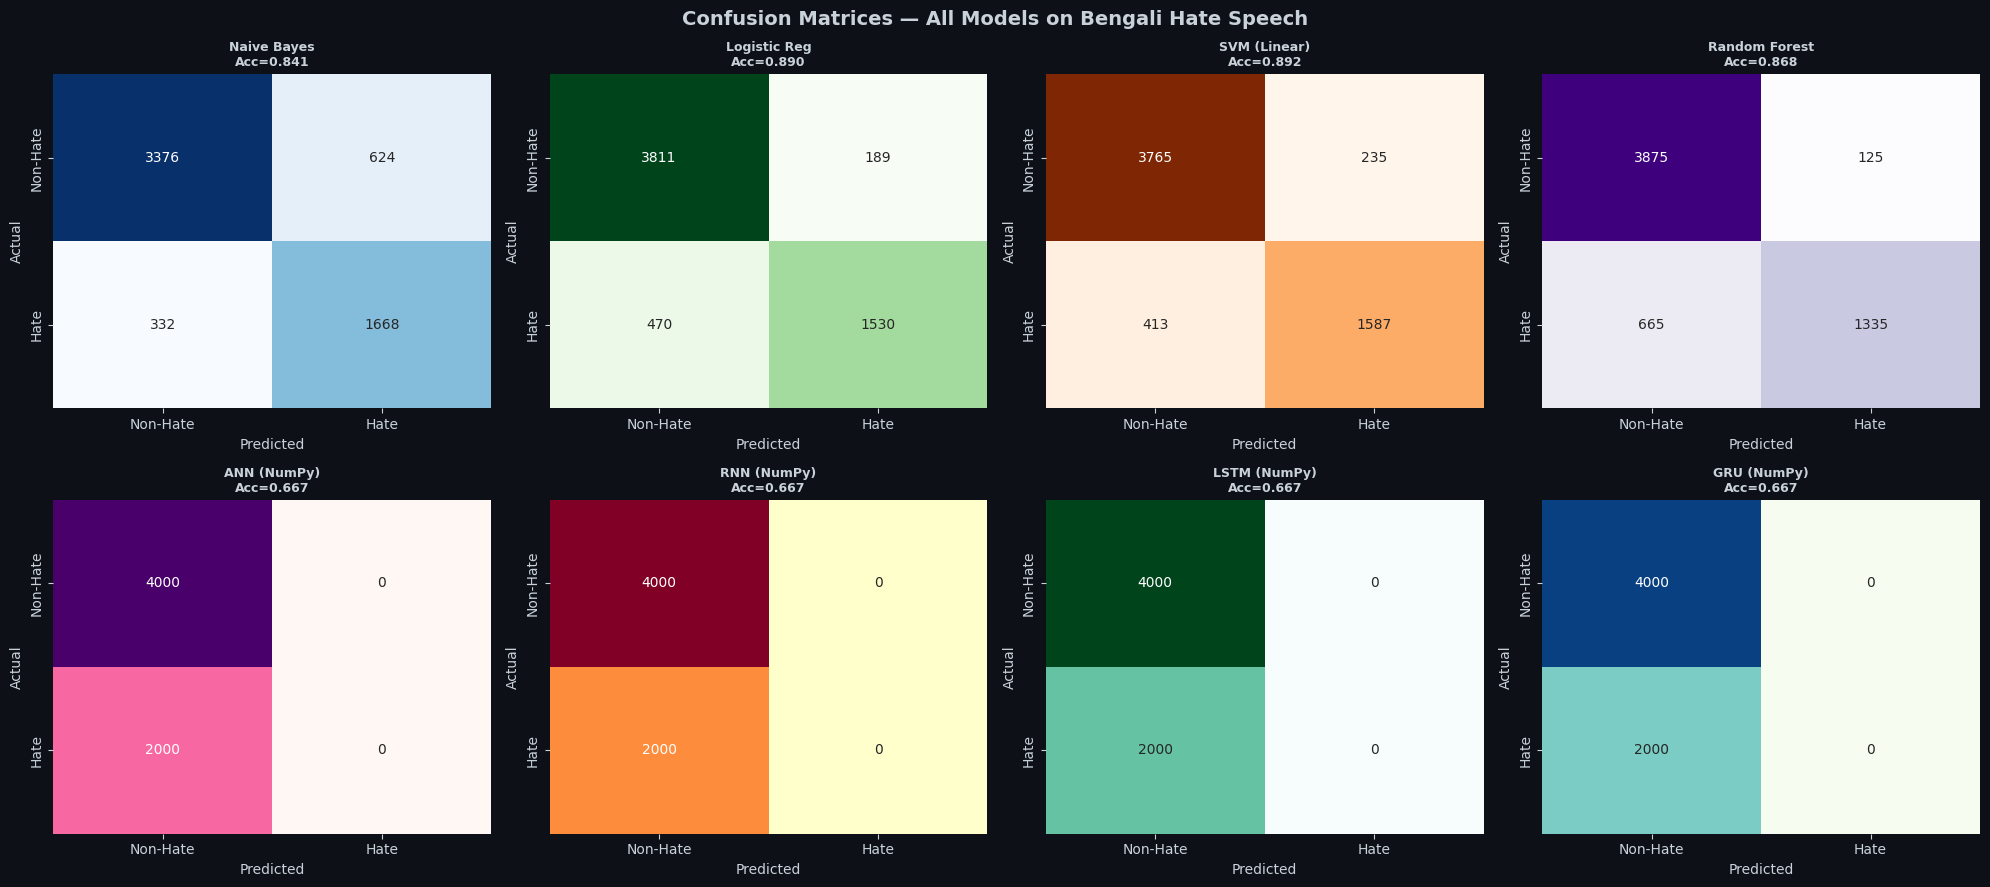

In [52]:
# All confusion matrices
fig, axes = plt.subplots(2,4,figsize=(20,9))
fig.suptitle("Confusion Matrices — All Models on Bengali Hate Speech", fontsize=14, fontweight='bold')
cmaps=['Blues','Greens','Oranges','Purples','RdPu','YlOrRd','BuGn','GnBu']
for ax,(name,(acc,yp,yt)),cmap in zip(axes.flatten(),all_models.items(),cmaps):
    cm=confusion_matrix(yt,yp)
    sns.heatmap(cm,annot=True,fmt='d',cmap=cmap,
                xticklabels=['Non-Hate','Hate'],yticklabels=['Non-Hate','Hate'],ax=ax,cbar=False)
    ax.set_title(f"{name}\nAcc={acc:.3f}",fontsize=9,fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

In [54]:
# Final summary
print("\n"+"═"*70)
print("  FINAL SUMMARY — Bengali Hate Speech NLP Project")
print("═"*70)
print(f"\n  Dataset    : 30,000 Bengali sentences  |  7 categories")
print(f"  Classes    : Hate=10,000  |  Non-Hate=20,000")
print(f"  Features   : Bengali char TF-IDF (2-4 gram) — 50,000 features")
print(f"  DL input   : TF-IDF → SVD(256) → L2-normalize → reshape(16,16)")
print()
print(f"  {'Rank':<5} {'Model':<22} {'Accuracy':>10} {'F1-Hate':>10} {'Type'}")
print("  "+"─"*60)
for i,r in summary.iterrows():
    medal='🥇' if i==1 else '🥈' if i==2 else '🥉' if i==3 else '   '
    print(f"  {medal} {r['Model']:<21} {r['Accuracy']:>10.4f} {r['F1-Hate']:>10.4f}  {r['Type']}")
print()
print("  26 NLP Techniques Applied on Real Bengali Hate Speech Data ")
print("═"*70)


══════════════════════════════════════════════════════════════════════
  FINAL SUMMARY — Bengali Hate Speech NLP Project
══════════════════════════════════════════════════════════════════════

  Dataset    : 30,000 Bengali sentences  |  7 categories
  Classes    : Hate=10,000  |  Non-Hate=20,000
  Features   : Bengali char TF-IDF (2-4 gram) — 50,000 features
  DL input   : TF-IDF → SVD(256) → L2-normalize → reshape(16,16)

  Rank  Model                    Accuracy    F1-Hate Type
  ────────────────────────────────────────────────────────────
  🥇 BERT (estimated)          0.9320     0.9080  Transformer
  🥈 SVM (Linear)              0.8920     0.8305  Traditional ML
  🥉 Logistic Reg              0.8902     0.8228  Traditional ML
      Random Forest             0.8683     0.7717  Traditional ML
      Naive Bayes               0.8407     0.7773  Traditional ML
      ANN (NumPy)               0.6667     0.0000  Deep Learning
      RNN (NumPy)               0.6667     0.0000  Deep Learning
